<a href="https://colab.research.google.com/github/Renata-Bilotti/Hackatho-Grupo-4/blob/Correcciones-parciales/Hacathon_Grupo_4_Mercado_de_Alfalfa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Hacathon: Comercio Internacional de Alfalfa y oportunidades comerciales para Argentina**

**Objetivo**: El siguente trabajo final busca caracterizar el mercado internacional de alfalfa y analizar la posición de Argentina dentro de ese mercado: nuestro rol como exportadores, y el comportamiento de la demanda global del producto analizado.

A partir de ese diagónstico se buscará identificar oportunidades comerciales:
*   Identificar los grandes mercados importadores que hoy no están siendo suficientemente atendidos por las exportaciones argentinas.
*   Entrenar un modelo regresión lineal múltiple para predecir el precio de exportación de la alfalfa, evaluando si la estacionalidad u otra variable influye de forma significativa.

La base de datos contará con 4 dataframe que se analizarán por separado en primera instancia, y luego se cruzarán, a fin de obtener los resultados esperados. A continuación se cargarán y se explicará brevemente cada uno.

###**Resumen de lo realizado:**

*   Análisis Exploratorio de Datos (EDA): análisis exploratorios clásicos para conocer las características y variables de cada dataframe: mercado mudial y la posición de Argentina, estructura del mercado exportador argentino, destino y cruce con la demanda mundial para detectar oportunidades.
*   Preprocesamiento: construcción del precio por kilogramo, tratamiento de outliers y creación de la variable estación.
*   Análisis de correlación entre variables numéricas.
*   Modelo: Regresión Lineal Múltiple, se probarán diferents modelos (statsmodels, sklearn y Catboots), con evaluación de métricas y de los supuestos del modelo (residuos).





--------------------------------------------------------------------------------
#1. Carga de librerías
--------------------------------------------------------------------------------
Todas las librerías utilizadas en este colab se encuentran a continuación, de forma que solo hay que correrlas una vez

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import statsmodels.stats.api as smf
from statsmodels.compat import lzip
from scipy.stats import shapiro

!pip install catboost --quiet
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


--------------------------------------------------------------------------------
#2. Carga de Datos
--------------------------------------------------------------------------------
El archivo es de tipo excel, y contiene 4 hojas: exportaciones globales (UN Comtrade), importaciones globales (UN Comtrade), exportaciones argentinas (Softrade) e importaciones globales desagregadas por empresa y socio comercial (Softrade).

Debido a que la base de datos se encuentra dividida en 4 hojas, se crearán 4 datafame, que se analizarán por separado en el EDA y posteriormente se cruzarán para contestar a los objetivos del trabajo.

Aclaraciones:
1. Exportaciones mundiales: df_expo_mundo
2. Importaciones mundiales: df_impo_mundo
3. Exportaciones Argentinas: df_expo_arg
4. Detalle de importaciones por empresa: df_impo_empresa

In [ ]:
#Subida de archivo de forma manual, desde los archivos presentes en la computadora
#(El excel se encuentra disponible en Github para su descarga)

from google.colab import files
uploaded = files.upload()

Saving TradeData- alfalfa - definitiva.xlsx to TradeData- alfalfa - definitiva.xlsx


In [ ]:

#Para evitar errores se le asigna FILENAME al nombre completo del archivo, ya que es
#extenso y con muchos espacios

FILENAME = 'TradeData- alfalfa - definitiva.xlsx'

df_expo_mundo = pd.read_excel(FILENAME, sheet_name = 'EXPO_Comtrade') #Exportaciones mundiales por país y por año
df_impo_mundo = pd.read_excel(FILENAME, sheet_name = 'IMPO_Comtrade') #Importaciones mundiales por país y por año
df_expo_arg = pd.read_excel(FILENAME, sheet_name = 'EXPO ARG_detalle_Softrade') #Detalle de exportaciones argentinas
df_impo_empresa = pd.read_excel(FILENAME, sheet_name = 'IMPO_empresa_Softrade') #Importaciones mundiales por empresa

In [ ]:
#Corroboración de la correcta subida de los df
#Exportaciones mundiales
df_expo_mundo.head()


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,32,ARG,Argentina,X,...,4.482024e+06,False,0.000,False,NaN,3456513.000,3456513.000,0,False,True
1,C,A,20240101,2024,52,2024,36,AUS,Australia,X,...,1.064254e+07,False,10642.529,False,NaN,4040253.087,4040253.087,0,False,True
2,C,A,20240101,2024,52,2024,40,AUT,Austria,X,...,1.090633e+06,False,0.000,False,NaN,376431.359,376431.359,0,False,True
3,C,A,20240101,2024,52,2024,48,BHR,Bahrain,X,...,8.600000e+03,False,0.000,False,NaN,1277.660,1277.660,0,False,True
4,C,A,20240101,2024,52,2024,56,BEL,Belgium,X,...,1.530182e+06,True,0.000,False,NaN,582970.848,582970.848,6,False,True


In [ ]:
#Corroboración de la correcta subida de los df
#Importaciones mundiales
df_impo_mundo.head()


,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,24,AGO,Angola,M,...,2730.00,False,0.0,False,1053.410,NaN,1053.410,0,False,True
1,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,653.76,False,0.0,False,645.996,NaN,645.996,0,False,True
2,C,A,20240101,2024,52,2024,32,ARG,Argentina,M,...,7425.00,False,0.0,False,1740.500,1039.500,1740.500,0,False,True
3,C,A,20240101,2024,52,2024,36,AUS,Australia,M,...,640.20,False,0.0,False,5697.347,5245.955,5697.347,0,False,True
4,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,10770632.00,False,0.0,False,3280935.463,NaN,3280935.463,0,False,True


In [ ]:
#Corroboración de la correcta subida de los df
#Exportaciones argentinas
df_expo_arg.head()



,Identificador,Item,Fecha,Estado,NCM-SIM,Exportador,Localidad,Tipo de Dato,Fecha Cumplido,Fecha Cargado,...,Marca - Sufijos,Cantidad.1,Unitario Divisa,FOB Divisa,Moneda Divisa,Condición de Venta,Marca o Descripcion,Descripcion Arancelaria,ES CÓRDOBA?,ES CLÚSTER?
0,24083EC01000004A,1,2024-01-02,CANC,1214.10.00.000F,LA CHITA SRL,SAN LUIS,DEFINITIVO,02/01/2024,No disponible,...,`,27.0,180.00,4860.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
1,24083EC01000005B,1,2024-01-02,CANC,1214.10.00.000F,LA CHITA SRL,SAN LUIS,DEFINITIVO,02/01/2024,No disponible,...,`,27.0,180.00,4860.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
2,24016EC01000011R,1,2024-01-03,CANC,1214.10.00.000F,ALFABAN S.R.L.,TRANSITO,DEFINITIVO,03/01/2024,No disponible,...,`,28.0,225.00,6300.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,SI,NO
3,24055EC01000026D,1,2024-01-05,CANC,1214.10.00.000F,No disponible,CIUDAD AUTONOMA,DEFINITIVO,05/01/2024,No disponible,...,`,52.0,150.78,7840.56,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO
4,24001EC01001231Z,1,2024-01-08,CANC,1214.10.00.000F,EQUIDIET COMPANY SA,TORTUGUITAS,DEFINITIVO,08/01/2024,No disponible,...,`,400.0,7.50,3000.00,DOLAR USA,FCA,`,HARINA Y PELLETS DE ALFALFA,NO,NO


In [ ]:
#Corroboración de la correcta subida de los df
#Importaciones por empresa
df_impo_empresa.head()

,NCM,AÑO,País de Empresa,Empresa,Operaciones,Valor U$S,Kilos,Socios Comerciales
0,1214.1,2024,Lesoto,"SESHEMANE, MAHLOMOLA PHILLIP\nLEBIPI MOTHOBI\n...",722,4339440.0,3676559.0,Sudáfrica
1,1214.1,2024,Lesoto,DENTECH (PTY) LTD\nMOSHOESHOE ROAD\nNO.10 RESC...,140,755346.0,1865265.0,Sudáfrica
2,1214.1,2024,Lesoto,FOOD INN (PTY) LTD\nP.O. BOX 31\nLERIBE 300,87,861340.0,2755100.0,Sudáfrica
3,1214.1,2024,Lesoto,"MOKHELE, LOUIS TSIETSI\nMOPELI MOPELI\nHA MOPELI",72,376472.0,1248018.0,Sudáfrica
4,1214.1,2024,Lesoto,RIVERSIDE FRESH FARM PRODUCE (PTY) LTD\nMALEFE...,62,391750.0,1128692.0,Sudáfrica


# 2.1 Información sobre cada dataframe:

Para observar la información de cada df se utilizará a continuación la función .info

In [ ]:
#Exportaciones mundiales

df_expo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  201 non-null    object 
 1   freqCode                  201 non-null    object 
 2   refPeriodId               201 non-null    int64  
 3   refYear                   201 non-null    int64  
 4   refMonth                  201 non-null    int64  
 5   period                    201 non-null    int64  
 6   reporterCode              201 non-null    int64  
 7   reporterISO               201 non-null    object 
 8   reporterDesc              201 non-null    object 
 9   flowCode                  201 non-null    object 
 10  flowDesc                  201 non-null    object 
 11  partnerCode               201 non-null    int64  
 12  partnerISO                201 non-null    object 
 13  partnerDesc               201 non-null    object 
 14  partner2Co

In [ ]:
# Importaciones mundiales

df_impo_mundo.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  312 non-null    object 
 1   freqCode                  312 non-null    object 
 2   refPeriodId               312 non-null    int64  
 3   refYear                   312 non-null    int64  
 4   refMonth                  312 non-null    int64  
 5   period                    312 non-null    int64  
 6   reporterCode              312 non-null    int64  
 7   reporterISO               312 non-null    object 
 8   reporterDesc              312 non-null    object 
 9   flowCode                  312 non-null    object 
 10  flowDesc                  312 non-null    object 
 11  partnerCode               312 non-null    int64  
 12  partnerISO                312 non-null    object 
 13  partnerDesc               312 non-null    object 
 14  partner2Co

In [ ]:
#Exportaciones argentinas

df_expo_arg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Identificador            2607 non-null   object        
 1   Item                     2607 non-null   int64         
 2   Fecha                    2607 non-null   datetime64[ns]
 3   Estado                   2607 non-null   object        
 4   NCM-SIM                  2607 non-null   object        
 5   Exportador               2607 non-null   object        
 6   Localidad                2607 non-null   object        
 7   Tipo de Dato             2607 non-null   object        
 8   Fecha Cumplido           2607 non-null   object        
 9   Fecha Cargado            2607 non-null   object        
 10  Destinación              2607 non-null   object        
 11  Aduana                   2607 non-null   object        
 12  Via Transporte           2607 non-

In [ ]:
#Detalle de importaciones por empresa

df_impo_empresa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NCM                 1307 non-null   float64
 1   AÑO                 1307 non-null   int64  
 2   País de Empresa     1307 non-null   object 
 3   Empresa             1307 non-null   object 
 4   Operaciones         1307 non-null   int64  
 5   Valor U$S           1307 non-null   float64
 6   Kilos               1307 non-null   float64
 7   Socios Comerciales  1307 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 81.8+ KB


## 2.2 Conversión de variables numéricas a categóricas y eliminación de variables innecesarias:

En el EDA se observó que algunas variables como period, que hace referencia al año en el cual se realizó la transacción, fueron categorizadas como "enteros" cuando en realidad funcionan como una variable categórica.

Se las transformará.

Además, como se observó con la función .head, cada df contiene muchas variables, es decir muchas columnas. En base a los objetivos y preguntas que se busca responder, se dejarán unicamente aquellas columnas que sean de importancia y se eliminarán las que no sean necesarias.

Esto es relativamente importante en los df de importación y exportación mundial, ya que cada una presenta 47 columnas pero solo se utilizarán unas pocas variables.

Para ello se utilizará la función drop. y se nombrarán todas las columnas a eliminar. Luego se corroborará la correcta eliminación.

In [ ]:
#Transformación de variables de números enteros a categóricas:

# Exportaciones mundiales
for df in [df_expo_mundo, df_impo_mundo]:
    df['period']  = df['period'].astype(str)   # año: 2024, 2025
    df['cmdCode'] = df['cmdCode'].astype(str)   # código NCM internacional

# Exportaciones argentinas (Softrade)
df_expo_arg['NCM-SIM'] = df_expo_arg['NCM-SIM'].astype(str)

# Importaciones por empresa
df_impo_empresa['NCM']  = df_impo_empresa['NCM'].astype(str)
df_impo_empresa['AÑO']  = df_impo_empresa['AÑO'].astype(str)

# Verificación rápida
print("=== df_expo_mundo ===")
print(df_expo_mundo[['period', 'cmdCode']].dtypes)
print(df_expo_mundo['period'].unique())
print(df_expo_mundo['cmdCode'].unique())

print("\n=== df_expo_arg ===")
print(df_expo_arg[['NCM-SIM']].dtypes)
print(df_expo_arg['NCM-SIM'].unique())

print("=== df_impo_empresa ===")
print(df_impo_empresa[['AÑO', 'NCM']].dtypes)
print(df_impo_empresa['AÑO'].unique())
print(df_impo_empresa['NCM'].unique())


=== df_expo_mundo ===
period     object
cmdCode    object
dtype: object
['2024' '2025']
['121410' '121490']

=== df_expo_arg ===
NCM-SIM    object
dtype: object
['1214.10.00.000F' '1214.90.00.900T']
=== df_impo_empresa ===
AÑO    object
NCM    object
dtype: object
['2024' '2025']
['1214.1' '1214.9']


In [ ]:
import pandas as pd

#Exportaciones mundiales:

#Solo se conservarán las columnas que se utilizarán en el EDA.
#Como drop. solo permite elegir 1 o 2 variables a eliminar, primero se creó una lista
#con todas las variables que se quieren eliminar y luego se utilizó dicha lista
#como argumento de la función .drop

columnas_a_eliminar_expo_mundo = [
    'typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'reporterCode', 'reporterISO',
    'flowCode', 'partnerCode', 'partnerISO', 'partner2Code', 'partner2ISO',
    'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification',
    'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc',
    'qtyUnitCode', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
    'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated',
    'cifvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate']

df_expo_mundo = df_expo_mundo.drop(columns = columnas_a_eliminar_expo_mundo)
df_expo_mundo.head()

,period,reporterDesc,flowDesc,partnerDesc,cmdCode,cmdDesc,qtyUnitAbbr,qty,fobvalue
0,2024,Argentina,Export,World,121410,Lucerne (alfalfa) meal and pellets,kg,4.482024e+06,3456513.000
1,2024,Australia,Export,World,121410,Lucerne (alfalfa) meal and pellets,kg,1.064254e+07,4040253.087
2,2024,Austria,Export,World,121410,Lucerne (alfalfa) meal and pellets,kg,1.090633e+06,376431.359
3,2024,Bahrain,Export,World,121410,Lucerne (alfalfa) meal and pellets,kg,8.600000e+03,1277.660
4,2024,Belgium,Export,World,121410,Lucerne (alfalfa) meal and pellets,kg,1.530182e+06,582970.848


Detalle de las variables que usaremos en el análisis:
- **Period**: periodo de tiempo analizado. Desagregado ANUAL.
- **ReporterDesc**:país reportante de la actividad comercial internacional.
- **FlowDesc**:tipo de flujo de comercio internacional analizado. En este caso EXPORTACIONES.
- **PartnerDesc**:destino del movimiento de comercio internacional. En este caso el dato es MUNDO, indicando que se muestran todos los movimientos de exportación del producto analizado de cada país reportante, hacia todos los destinos.
- **CmdCode**:código nomenclador de los productos analizados, bajo el sistema numérico estandarizado que identifica y clasifica las mercancias para el control aduanero, pago de aranceles y estadísticas comerciales.  
- **CmdDesc**: descripción de producto para la nomenclatura analizada.
- **QtyUnitAbbr**: unidad de medida de la cantidad de producto exportado.
- **Qty**: cantidad de producto exportado analizado.
- **FOBValue**:valor total en USD de la exportación analizada del producto, calculada en el puerto de origen, que incluyen todos los gastos hasta que el producto esté cargado en el medio de transporte.

In [ ]:
#Importaciones mundiales:

#Mismo criterio y procedimiento utilizado para las Exportaciones mundiales

columnas_a_eliminar_impo_mundo = [
    'typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'reporterCode', 'reporterISO',
    'flowCode', 'partnerCode', 'partnerISO', 'partner2Code', 'partner2ISO',
    'partner2Desc', 'classificationCode', 'classificationSearchCode', 'isOriginalClassification',
    'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc', 'mosCode', 'motCode', 'motDesc',
    'qtyUnitCode', 'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
    'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt', 'isGrossWgtEstimated',
    'fobvalue', 'primaryValue', 'legacyEstimationFlag', 'isReported', 'isAggregate'
]

df_impo_mundo = df_impo_mundo.drop(columns = columnas_a_eliminar_impo_mundo)
df_impo_mundo.head()


,period,reporterDesc,cmdCode,cifvalue
0,2024,Angola,121410,1053.410
1,2024,Antigua and Barbuda,121410,645.996
2,2024,Argentina,121410,1740.500
3,2024,Australia,121410,5697.347
4,2024,Austria,121410,3280935.463


Detalle de las variables que usaremos en el análisis:
- **Period**: periodo de tiempo analizado. Desagregado ANUAL.
- **ReporterDesc**:país reportante de la actividad comercial internacional.
- **FlowDesc**: tipo de flujo de comercio internacional analizado. En este caso IMPORTACIONES.
- **PartnerDesc**: origen del movimiento de comercio internacional. En este caso el dato es MUNDO, indicando que se muestran todos los movimientos de importación del producto analizado de cada país reportante, desde todos los origenes.
- **CMDCode**: código nomenclador de los productos analizados, bajo el sistema numérico estandarizado que identifica y clasifica las mercancias para el control aduanero, pago de aranceles y estadísticas comerciales.  
- **CMDDesc**: descripción de producto para la nomenclatura analizada.
- **QtyUnitAbbr**: unidad de medida de la cantidad de producto importado
- **Qty**: cantidad de producto importado analizado.
- **CIFValue**: valor total en USD de la importación analizada del producto, incluyendo costo del producto, transporte internacional por vía marítima o fluvial, y el seguro de la carga hasta el puerto de destino.

In [ ]:
#Exportaciones Argentinas:

#Se eliminan columnas redundantes y además se elimina la columna de U$D Unitario ya
#que este mezcla unidades y no es comparable entre diferentes transacciones

columnas_a_eliminar_expo_arg = [
    'Identificador', 'Item', 'Estado', 'Tipo de Dato', 'Fecha Cumplido', 'Fecha Cargado',
    'Destinación', 'Aduana de Destino', 'U$S Unitario', 'Flete U$S', 'Seguro',
    'Item.1', 'Marca - Sufijos', 'Cantidad.1', 'Unitario Divisa', 'FOB Divisa', 'Moneda Divisa',
    'Marca o Descripcion', 'Kgs. Netos'
]

df_expo_arg = df_expo_arg.drop(columns = columnas_a_eliminar_expo_arg)
df_expo_arg.head()


,Fecha,NCM-SIM,Exportador,Localidad,Aduana,Via Transporte,País de Destino,U$S FOB,Cantidad,Kgs. Netos,Condición de Venta,ES CÓRDOBA?,ES CLÚSTER?
0,2024-01-02,1214.10.00.000F,LA CHITA SRL,SAN LUIS,SAN LUIS,CAMION,Colombia,4860.00,27.0,27000.0,FCA,NO,NO
1,2024-01-02,1214.10.00.000F,LA CHITA SRL,SAN LUIS,SAN LUIS,CAMION,Colombia,4860.00,27.0,27000.0,FCA,NO,NO
2,2024-01-03,1214.10.00.000F,ALFABAN S.R.L.,TRANSITO,CONCORDIA,CAMION,Uruguay,6300.00,28.0,28000.0,FCA,SI,NO
3,2024-01-05,1214.10.00.000F,No disponible,CIUDAD AUTONOMA,SAN JUAN,CAMION,Chile,7840.56,52.0,56004.0,FCA,NO,NO
4,2024-01-08,1214.10.00.000F,EQUIDIET COMPANY SA,TORTUGUITAS,BS.AS. (CAPITAL),CAMION,Bolivia,3000.00,400.0,10000.0,FCA,NO,NO


Detalle de las variables que usaremos en el análisis:
- **Fecha**:fecha de concreción de la operación de comercio internacional analizada.
- **NCM-SIM**:código nomenclador de los productos analizados, bajo el sistema numérico estandarizado que identifica y clasifica las mercancias para el control aduanero, pago de aranceles y estadísticas comerciales.
- **Exportador**: nombre o razón social de la empresa argentina que registra el movimiento de comercio internacional.
- **Localidad**:provincia argentina (también incluye CABA) en donde la empresa exportadora tiene registrada la razón social, donde se establece oficialmente su domicilio legal y sede principal.
- **Aduana**:aduana de salida, oficial fiscal donde la empresa declara su mercancía. En este punto geográfico se concreta el control de los papeles y se autoriza legalmente la salida del producto del país.
- **Vía Transporte**: tipo de transporte en el que se concreta la salida de la mercadería desde la aduana de salida.
- **País de destino**: destino global de la mercadería exportada. La desagregación es a nivel PAÍS.
- **U$D FOB**: valor total en USD de la exportación analizada del producto, calculada en el puerto de origen, que incluyen todos los gastos hasta que el producto esté cargado en el medio de transporte.
- **Cantidad**:cantidad de producto exportado analizado.
- **Unidad**: unidad de medida de la cantidad de producto importado.
- **Condición de venta**: punto exacto del viaje donde se traspasan los costos y riesgos entre el exportador y el importador.
- **Descripción arancelaria**: descripción de producto para la nomenclatura analizada.
- **Es Córdoba?**: indica por SI/NO el registro de la empresa exportadora analizada en la Provincia de Córdoba, Argentina.
- **Es Clúster?**: indica por SI/NO la pertenencia de las empresas registradas en la Provincia de Córdoba a algún Clúster del Programa Córdoba Clúster, de la Agencia Competitividad, Gobierno de la Provincia de Córdoba.

In [ ]:

df_impo_empresa.head(30)

,NCM,AÑO,País de Empresa,Empresa,Operaciones,Valor U$S,Kilos,Socios Comerciales
0,1214.1,2024,Lesoto,"SESHEMANE, MAHLOMOLA PHILLIP\nLEBIPI MOTHOBI\n...",722,4339440.00,3676559.0,Sudáfrica
1,1214.1,2024,Lesoto,DENTECH (PTY) LTD\nMOSHOESHOE ROAD\nNO.10 RESC...,140,755346.00,1865265.0,Sudáfrica
2,1214.1,2024,Lesoto,FOOD INN (PTY) LTD\nP.O. BOX 31\nLERIBE 300,87,861340.00,2755100.0,Sudáfrica
3,1214.1,2024,Lesoto,"MOKHELE, LOUIS TSIETSI\nMOPELI MOPELI\nHA MOPELI",72,376472.00,1248018.0,Sudáfrica
4,1214.1,2024,Lesoto,RIVERSIDE FRESH FARM PRODUCE (PTY) LTD\nMALEFE...,62,391750.00,1128692.0,Sudáfrica
5,1214.1,2024,Lesoto,"MAHOMED, AMAD\nP.O. BOX 166\nLERIBE 300",58,23389.00,170590.0,Sudáfrica
6,1214.1,2024,Lesoto,"RANOKA, TSELANGOE\nMAJARA SEEISO\nCIRCLE\nMATL...",55,31022.00,165.0,Sudáfrica
7,1214.1,2024,Lesoto,K.B.T. JANDRELL & COMPANY (PTY) LTD\nMATSENOLO...,53,92974.00,159.0,Sudáfrica
8,1214.1,2024,Lesoto,PB JANDRELL & SONS (PTY) LTD\nMATSENOLO BERENG...,49,107514.00,3144.0,Sudáfrica
9,1214.1,2024,Lesoto,"MAFATA, MALEFANE JOSEPH\nMAKARA NYENYE\nMOHALITOE",48,15834.00,203163.0,Sudáfrica


Descripción de las variables que usaremos en el análisis:
- **NCM**:código nomenclador de los productos analizados, bajo el sistema numérico estandarizado que identifica y clasifica las mercancias para el control aduanero, pago de aranceles y estadísticas comerciales.
- **AÑO**:período anual de concreción de la operación de comercio internacional analizada.
- **País de empresa**: unidad nacional en donde la empresa exportadora tiene registrada la razón social, donde se establece oficialmente su domicilio legal y sede principal.
- **Empresa**:nombre o razón social de la empresa que registra el movimiento de comercio internacional.
- **Operaciones**: cantidad de movimientos de comercio internacional registrados por la empresa identificada en el período anual analizado.
- **Valor U$D**:valor total en U$D de las operaciones identificadas por la empresa en el período analizado.
- **Kilos**: cantidad total de las operaciones identificadas por la empresa en el período analizado.
- **Socios comerciales**: países que participan en la transacción de compra- venta de la mercadería analizada, con la empresa que se analiza y en el período analizado.


--------------------------------------------------------------------------------
# 3. Análisis Exporatorio de los Datos: observación detallada de cada df
--------------------------------------------------------------------------------
A continuación se realizará un EDA de cada uno de los dataframe utilizadps, para conocer cómo se distribuyen las variables y correlacciones entre las mismas.

Para esto se utilizarán las funciones .info y .decribe junto con recursos gráficos

# 3.1. Exportaciones mundiales:

In [ ]:
#Tipos de datos y cantidad de registros:

df_expo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   period        201 non-null    object 
 1   reporterDesc  201 non-null    object 
 2   flowDesc      201 non-null    object 
 3   partnerDesc   201 non-null    object 
 4   cmdCode       201 non-null    object 
 5   cmdDesc       201 non-null    object 
 6   qtyUnitAbbr   189 non-null    object 
 7   qty           201 non-null    float64
 8   fobvalue      201 non-null    float64
dtypes: float64(2), object(7)
memory usage: 14.3+ KB


In [ ]:
#Estadística descriptiva

df_expo_mundo.describe()

,qty,fobvalue
count,2.010000e+02,2.010000e+02
mean,7.528257e+07,2.734990e+07
std,3.964980e+08,1.354957e+08
min,0.000000e+00,5.500000e-01
25%,4.800000e+04,4.500300e+04
50%,1.090633e+06,5.496468e+05
75%,1.366017e+07,4.364248e+06
max,3.969724e+09,1.329192e+09


In [ ]:
#Valores faltantes

df_expo_mundo.isnull().sum()

,0
period,0
reporterDesc,0
cmdCode,0
fobvalue,0


In [ ]:
#Cantidad de países y códigos arancelarios

print('Cantidad de paises:', df_expo_mundo['reporterDesc'].nunique())
df_expo_mundo['cmdCode'].value_counts()

#Aclarar que es una variable de tipo caegórica y no numérica

Cantidad de paises: 79


,count
cmdCode,
121490,118
121410,83


El EDA muestra que el df correspondiente a exportaciones mundiales contiene 4 variables, de las cuales 3 son numéricas y una es de caracteres.

Dentro de las 3 variables numéricas se detallan:
* cmdCode: código identidicador del producto exportado
* period: corresponde al período de exportación, 2024 o 2025
* Fobvalue: corresponde al precio de alfalfa teniendo en cuenta el precio por kg, junto con otros gastos asociados como transporte y aduanas, lo que da el precio final de exportación del producto.

La variable categórica identifica el país de origne de la exportación (reporterDesc)

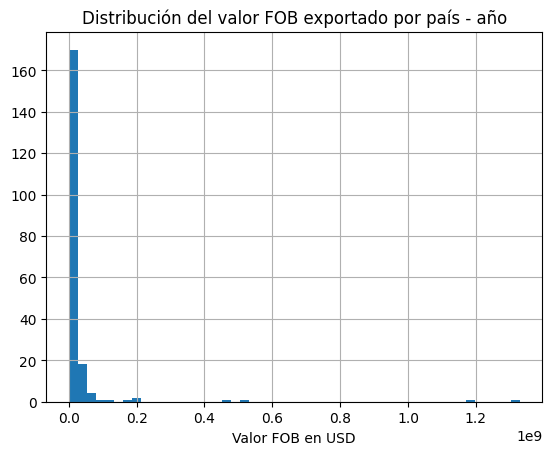

In [ ]:
#Histograma del valor exportado:

#Se busca observar cómo se distribuyen los montos en dólares exportados por cada país en
#cada año

df_expo_mundo['fobvalue'].hist(bins = 50)
plt.title('Distribución del valor FOB exportado por país - año')
plt.xlabel('Valor FOB en USD')
plt.show()

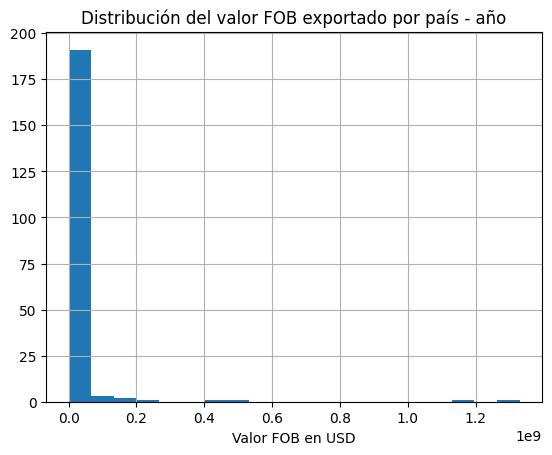

In [ ]:
#Histograma del valor exportado:

#Se busca observar cómo se distribuyen los montos en dólares exportados por cada país en
#cada año

df_expo_mundo['fobvalue'].hist(bins = 20)
plt.title('Distribución del valor FOB exportado por país - año')
plt.xlabel('Valor FOB en USD')
plt.show()

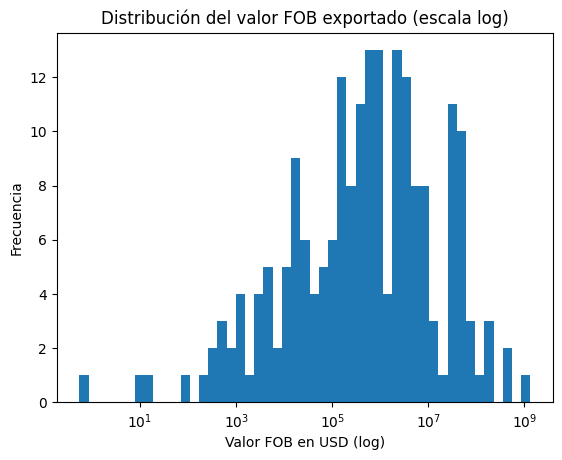

In [ ]:
import numpy as np

# Solo valores positivos (log no está definido en 0)
valores = df_expo_mundo[df_expo_mundo['fobvalue'] > 0]['fobvalue']

# Bins espaciados logarítmicamente entre el mínimo y el máximo
bins_log = np.logspace(np.log10(valores.min()), np.log10(valores.max()), 50)

plt.hist(valores, bins=bins_log)
plt.xscale('log')
plt.title('Distribución del valor FOB exportado (escala log)')
plt.xlabel('Valor FOB en USD (log)')
plt.ylabel('Frecuencia')
plt.show()

* 10¹ = 10 dólares
* 10³ = 1.000 dólares
* 10⁵ = 100.000 dólares
* 10⁷ = 10.000.000 dólares
* 10⁹ = 1.000.000.000 dólares (mil millones)




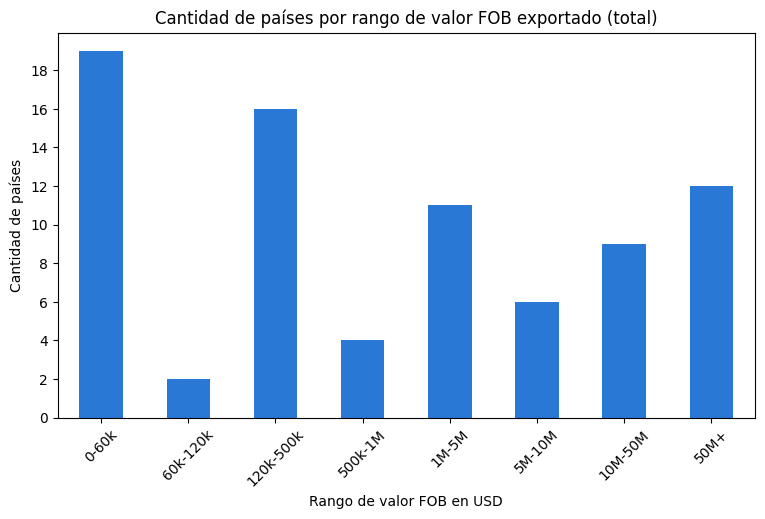

In [ ]:
# Paso 1: valor FOB total exportado por país (sumando todos los años)
valor_por_pais = df_expo_mundo.groupby('reporterDesc')['fobvalue'].sum()

# Paso 2: definir los rangos (bins) en dólares
bins = [0, 60000, 120000, 500000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, np.inf]
labels = ['0-60k', '60k-120k', '120k-500k', '500k-1M', '1M-5M', '5M-10M', '10M-50M', '50M+']

# Paso 3: clasificar cada país en su rango
categorias = pd.cut(valor_por_pais, bins=bins, labels=labels)

# Paso 4: contar cuántos países caen en cada rango
conteo_por_rango = categorias.value_counts().sort_index()



import matplotlib.ticker as ticker

plt.figure(figsize=(9,5))
conteo_por_rango.plot(kind='bar', color='#2a78d6')
plt.title('Cantidad de países por rango de valor FOB exportado (total)')
plt.xlabel('Rango de valor FOB en USD')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)

# Forzar el eje Y a mostrar solo números enteros
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.show()

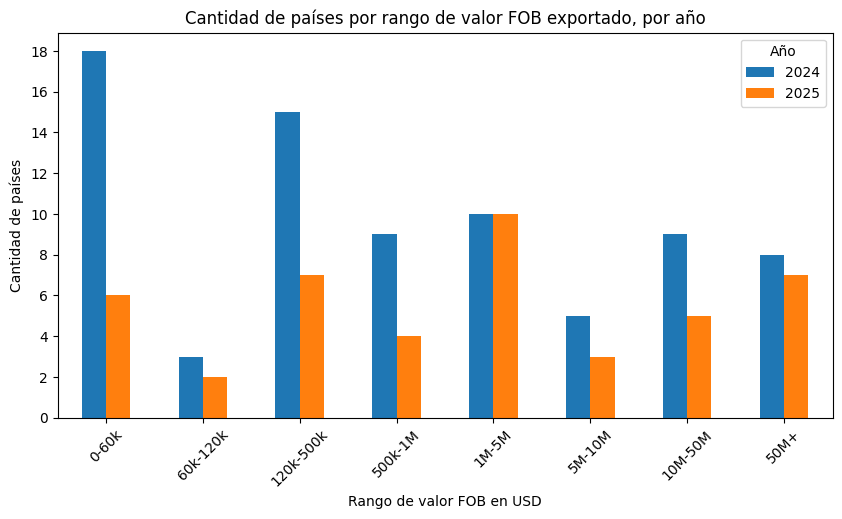

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker

# Valor FOB por país y año (en vez de sumar todos los años juntos)
valor_por_pais_anio = df_expo_mundo.groupby(['reporterDesc', 'period'])['fobvalue'].sum().reset_index()

bins = [0, 60000, 120000, 500000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, np.inf]
labels = ['0-60k', '60k-120k', '120k-500k', '500k-1M', '1M-5M', '5M-10M', '10M-50M', '50M+']

valor_por_pais_anio['rango'] = pd.cut(valor_por_pais_anio['fobvalue'], bins=bins, labels=labels)
conteo = valor_por_pais_anio.groupby(['rango', 'period'], observed=True).size().unstack(fill_value=0)

conteo.plot(kind='bar', figsize=(10,5))
plt.title('Cantidad de países por rango de valor FOB exportado, por año')
plt.xlabel('Rango de valor FOB en USD')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Año')
plt.show()

Text(0, 0.5, 'Valor FOB en USD')

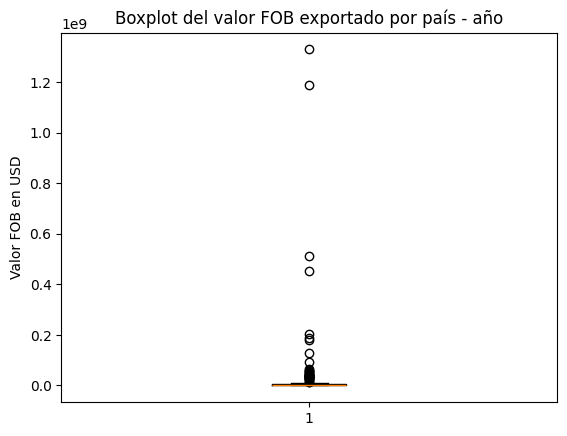

In [ ]:
#Boxplot del valor exportado

#Se busca observar si hay países con valores muy alejados del resto, es decir
#outliers

plt.boxplot(df_expo_mundo['fobvalue'])
plt.title('Boxplot del valor FOB exportado por país - año')
plt.ylabel('Valor FOB en USD')



Ya que dentro de este df el único valor cuantitativo de interés para graficar es Fobvalue, se obtuvieron un gráfico de histograma y otro de boxplot para esta variable. En ambos casos se observa que los datos tienen un sesgo importante, una grán agrupación de datos hacia la izquiera (histograma) y una grán cantidad de outliers (boxplot).

Estos resultados son de esperarse ya que las exportaciones incluyen tanto envíos muy grandes, cuyo Fobvalue es muy alto, junto con exportaciones más pequeñas, cuyo Fobvalue es mucho menor.

**En este cuadro de texto analizar los resultados obtenidos hasta aca y dar una explicación de los mismos**

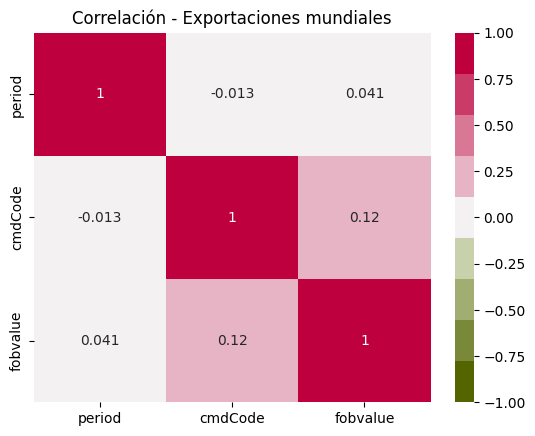

In [ ]:
#Correlación entre variables numéricas:

#Se observará rapidamente la relación entre las variables período (año),
#cmdCode (código del producto) y fobvalue (valor de alfalfa en dólares)

palette = sns.diverging_palette(100, 5, s=100, l=40, n=9) #paleta divergente que mejora la observación de la correlación
sns.heatmap(df_expo_mundo[['period', 'cmdCode','fobvalue']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Exportaciones mundiales')
plt.show()

No se observan importantes correlaciones entre las variables, ya que ningun valor de correlación es superior a 0,5. El Fobvalue no esta correlacionado con el período de exortación.

# 3.2 Importaciones Mundiales

In [ ]:
#Tipos de datos y cantidad de registros:
df_impo_mundo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   period        312 non-null    object 
 1   reporterDesc  312 non-null    object 
 2   cmdCode       312 non-null    object 
 3   cifvalue      302 non-null    float64
dtypes: float64(1), object(3)
memory usage: 9.9+ KB


In [ ]:
# Estadística descriptiva:
df_impo_mundo.describe()

#Aclarar que período es una variable categórica y no numérica

,cifvalue
count,3.020000e+02
mean,1.397649e+07
std,7.064087e+07
min,6.000000e+00
25%,3.524204e+04
50%,5.600261e+05
75%,3.640470e+06
max,6.699853e+08


In [ ]:
#Valores faltantes
df_impo_mundo.isnull().sum()

,0
period,0
reporterDesc,0
cmdCode,0
cifvalue,10


### 3.2.1 Valores faltantes de la variable cifvalue

Debido a que cifvalue es el valor total de la importación, sin ese valor no es posible analizar la operación, por lo cual se eliminarán los 10 registros donde no hay valores.

In [ ]:
#Eliminación de las 10 filas con valores faltantes:
df_impo_mundo = df_impo_mundo.dropna(subset=['cifvalue'])

#Corroboración:
df_impo_mundo.isnull().sum()

,0
period,0
reporterDesc,0
cmdCode,0
cifvalue,0


In [ ]:
filas_con_nulos = df_impo_mundo[df_impo_mundo.isnull().any(axis=1)]
print(filas_con_nulos)

Empty DataFrame
Columns: [period, reporterDesc, cmdCode, cifvalue]
Index: []


In [ ]:
print('Cantidad de paises:', df_impo_mundo['reporterDesc'].nunique())
df_impo_mundo['cmdCode'].value_counts()

Cantidad de paises: 116


,count
cmdCode,
121490,159
121410,143


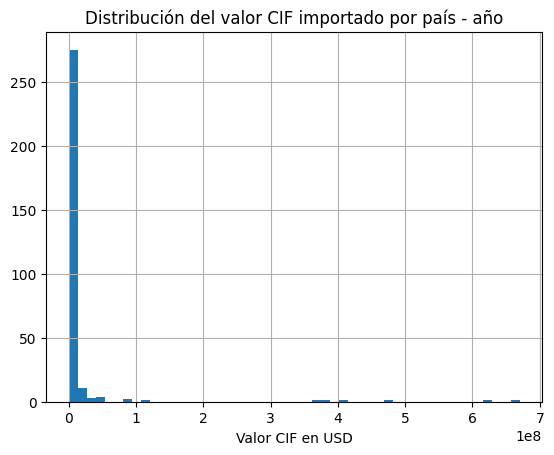

In [ ]:
#Histograma del valor importado
df_impo_mundo['cifvalue'].hist(bins = 50)
plt.title('Distribución del valor CIF importado por país - año')
plt.xlabel('Valor CIF en USD')
plt.show()

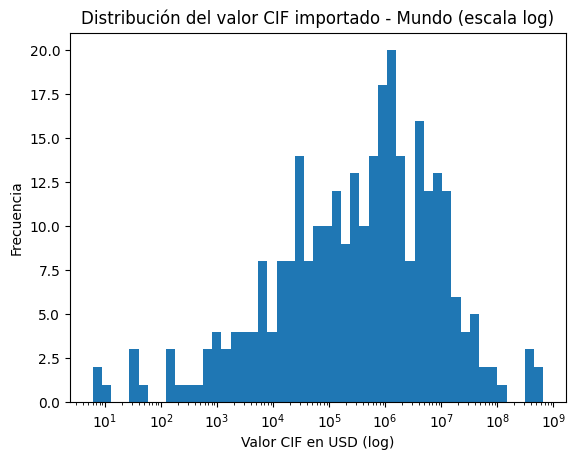

In [ ]:
valores_cif_mundo = df_impo_mundo[df_impo_mundo['cifvalue'] > 0]['cifvalue']
bins_log_cif_mundo = np.logspace(np.log10(valores_cif_mundo.min()), np.log10(valores_cif_mundo.max()), 50)

plt.hist(valores_cif_mundo, bins=bins_log_cif_mundo)
plt.xscale('log')
plt.title('Distribución del valor CIF importado - Mundo (escala log)')
plt.xlabel('Valor CIF en USD (log)')
plt.ylabel('Frecuencia')
plt.show()

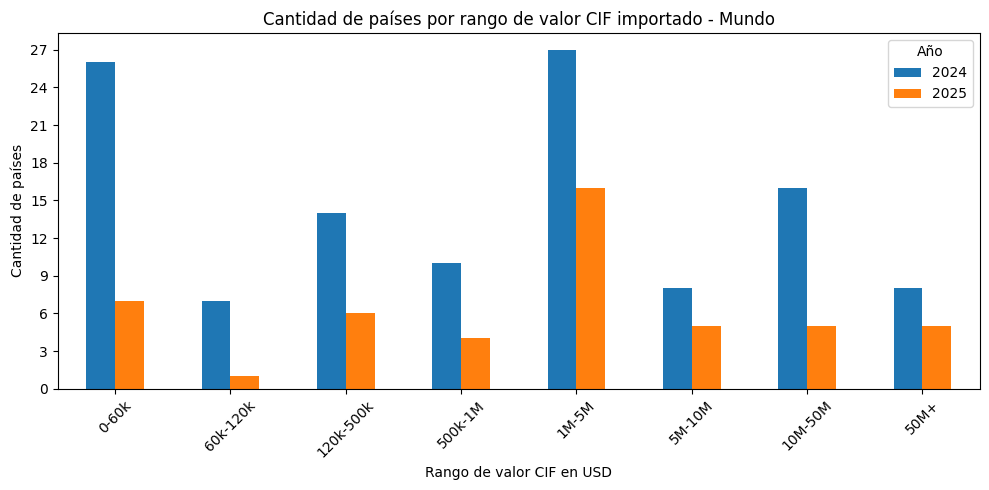

In [ ]:
valor_por_pais_anio_impo = df_impo_mundo.groupby(['reporterDesc', 'period'])['cifvalue'].sum().reset_index()

bins_impo = [0, 60000, 120000, 500000, 1_000_000, 5_000_000, 10_000_000, 50_000_000, np.inf]
labels_impo = ['0-60k', '60k-120k', '120k-500k', '500k-1M', '1M-5M', '5M-10M', '10M-50M', '50M+']

valor_por_pais_anio_impo['rango'] = pd.cut(valor_por_pais_anio_impo['cifvalue'], bins=bins_impo, labels=labels_impo)

conteo_impo = valor_por_pais_anio_impo.groupby(['rango', 'period'], observed=True).size().unstack(fill_value=0)

conteo_impo.plot(kind='bar', figsize=(10,5))
plt.title('Cantidad de países por rango de valor CIF importado - Mundo')
plt.xlabel('Rango de valor CIF en USD')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Año')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Valor CIF en USD')

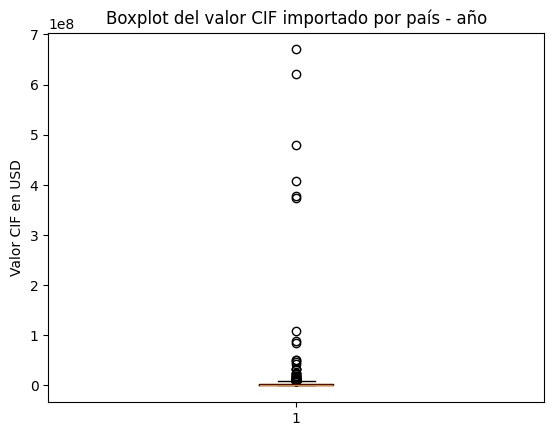

In [ ]:
#Boxplot del valor importado
plt.boxplot(df_impo_mundo['cifvalue'])
plt.title('Boxplot del valor CIF importado por país - año')
plt.ylabel('Valor CIF en USD')


Al igual que en el df de exportaciones mundiales, el valor CIF en importaciones mundiales tiene grán cantidad de outliers ya que se comparan operaciones muy grades con operaciones pequeñas.

**Explicar en este cuadro los resultados observados hasta acá**

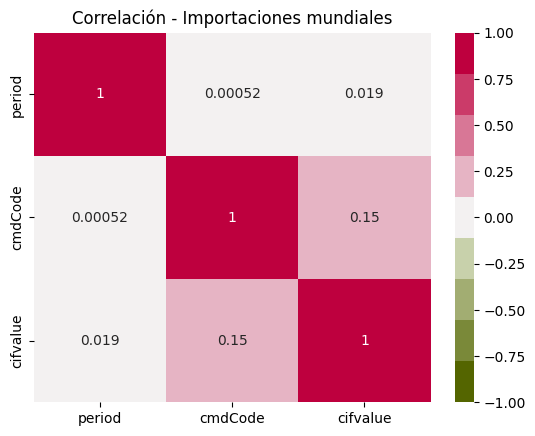

In [ ]:
#Correlación entre variables numéricas
sns.heatmap(df_impo_mundo[['period', 'cmdCode','cifvalue']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Importaciones mundiales')
plt.show()

**Explicar lo observado en la correlación**

# 3.3 Exportaciones Argentina

In [ ]:
#Tipos de datos y cantidad de registros:
df_expo_arg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2607 entries, 0 to 2606
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Fecha               2607 non-null   datetime64[ns]
 1   NCM-SIM             2607 non-null   object        
 2   Exportador          2607 non-null   object        
 3   Localidad           2607 non-null   object        
 4   Aduana              2607 non-null   object        
 5   Via Transporte      2607 non-null   object        
 6   País de Destino     2607 non-null   object        
 7   U$S FOB             2607 non-null   float64       
 8   Cantidad            2607 non-null   float64       
 9   Kgs. Netos          2607 non-null   float64       
 10  Condición de Venta  2607 non-null   object        
 11  ES CÓRDOBA?         2607 non-null   object        
 12  ES CLÚSTER?         2607 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(9)
memo

In [ ]:
#Estadística descriptiva de variables:
df_expo_arg.describe()

,Fecha,U$S FOB,Cantidad,Kgs. Netos
count,2607,2.607000e+03,2.607000e+03,2.607000e+03
mean,2025-02-15 11:40:56.616800768,4.382087e+04,2.603917e+03,1.130533e+05
min,2024-01-02 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024-09-06 00:00:00,9.527500e+02,2.013000e+01,1.591500e+04
50%,2025-02-17 00:00:00,4.437000e+03,5.280000e+01,2.700000e+04
75%,2025-08-25 00:00:00,1.478400e+04,2.398900e+02,8.401000e+04
max,2025-12-30 00:00:00,1.225000e+06,1.800000e+06,2.500000e+06
std,NaN,1.189994e+05,4.630103e+04,2.456806e+05


In [ ]:
#Estadística descriptiva de variables tipo numéricas:
df_expo_arg[['U$S FOB', 'Kgs. Netos', 'Cantidad']].describe()

,U$S FOB,Kgs. Netos,Cantidad
count,2.607000e+03,2.607000e+03,2.607000e+03
mean,4.382087e+04,1.130533e+05,2.603917e+03
std,1.189994e+05,2.456806e+05,4.630103e+04
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.527500e+02,1.591500e+04,2.013000e+01
50%,4.437000e+03,2.700000e+04,5.280000e+01
75%,1.478400e+04,8.401000e+04,2.398900e+02
max,1.225000e+06,2.500000e+06,1.800000e+06


In [ ]:
#Valores faltantes:
df_expo_arg.isnull().sum()

,0
Fecha,0
NCM-SIM,0
Exportador,0
Localidad,0
Aduana,0
Via Transporte,0
País de Destino,0
U$S FOB,0
Cantidad,0
Kgs. Netos,0


In [ ]:
#Cantidad de categorías por variable:

#Es necesario visualizar cada categoría de cada variable para comprender
#claramente qué significa cada una y luego interpretar correctamente los resultados
#sobre las mismas

for col in ['Exportador', 'Localidad','Aduana','Via Transporte','País de Destino','Condición de Venta']:
  print(col, '->', df_expo_arg[col].nunique(),'Valores únicos')

Exportador -> 44 Valores únicos
Localidad -> 29 Valores únicos
Aduana -> 17 Valores únicos
Via Transporte -> 4 Valores únicos
País de Destino -> 29 Valores únicos
Condición de Venta -> 7 Valores únicos


Debido a que hay variables con pocas categorías, a continuación se detallará cada una de ellas, ya que serán clave a posterior para analizar los resultados de correlación y regresión lineal

In [ ]:
#Vía de Transporte:
df_expo_arg['Via Transporte'].value_counts()

,count
Via Transporte,
CAMION,2538
FERROCARRIL,51
ACUATICA,17
AVION,1


In [ ]:
#Condición de venta:
df_expo_arg['Condición de Venta'].value_counts()

,count
Condición de Venta,
FCA,1673
FOB,898
CFR,16
CPT,10
CIF,4
CIP,4
EXW,2


Los INCOTERMS son reglas internacionales creadas por la Cámara de Comercio Internacional (CCI), que explicaran el momento y lugar de transferencia de la responsabilidad, los costos y los riesgos entre compradores y vendedores en una operación de compraventa internacional:

---
FCA -- *Free Carrier*: hasta que la mercadería esté en manos del transportista, en lugar y momento acordado.

FOB -- *Free on Board*: a bordo del buque, en el puerto de embarque convenido.

CFR -- *Cost and Freight*: incluye costo hasta el puerto de destino acordado, peo no incluye seguros contra riesgos.

CPT -- *Carriage Paid To*: el vendedor paga el costo del transporte acordado hasta el destino, pero el riesgo se traslada al comprador una vez entrega la mercadería al transportista.

CIF -- *Cost, Insurance and Freight*: incluye costo y riesgos de transporte hasta el puerto de destino acordado.

CIP -- *Carriage and Insurance Paid*: el vendedor paga el costo y el seguro hasta el destino acordado, pero el riesgo pasa al comprador al entregar la carga al transportista.

EXW-- *Ex Works*: el vendedor cumple con la entrega en las instalaciones del comprador, pero este último es el responsable de costos y riesgos a partir de ese momento.

In [ ]:
#Es Córdoba?
df_expo_arg['ES CÓRDOBA?'].value_counts()

,count
ES CÓRDOBA?,
SI,1379
NO,1228


In [ ]:
#Es cluster?
df_expo_arg['ES CLÚSTER?'].value_counts()

,count
ES CLÚSTER?,
NO,1787
SI,820


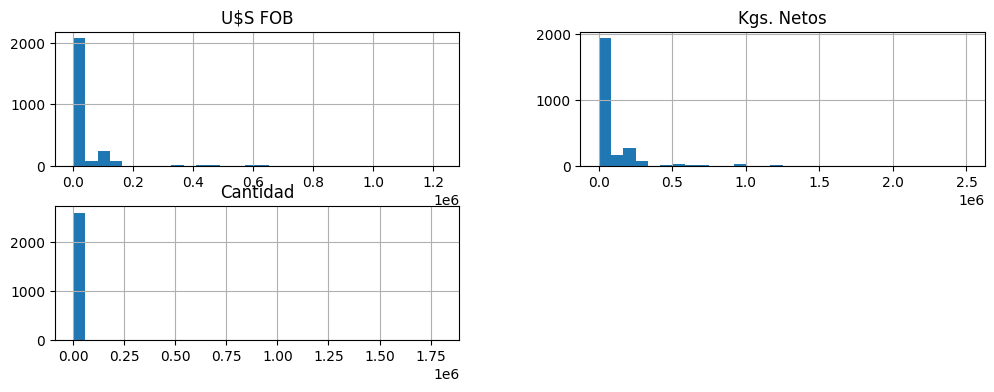

In [ ]:
#Histogramas de las variables numéricas:
df_expo_arg[['U$S FOB', 'Kgs. Netos','Cantidad']].hist(bins=30,figsize=(12,4))
plt.show()


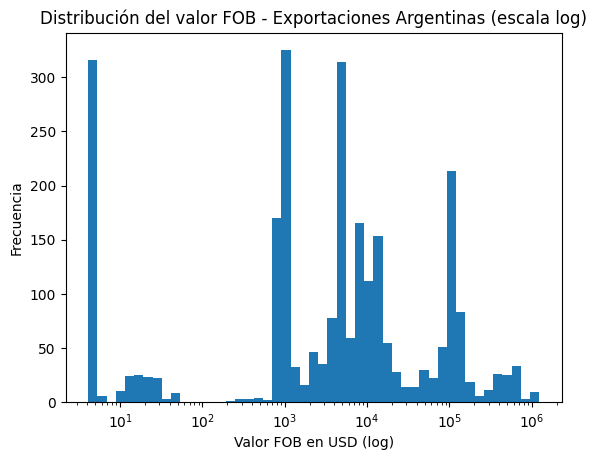

In [ ]:
valores_fob_arg = df_expo_arg[df_expo_arg['U$S FOB'] > 0]['U$S FOB']
bins_log_fob_arg = np.logspace(np.log10(valores_fob_arg.min()), np.log10(valores_fob_arg.max()), 50)

plt.hist(valores_fob_arg, bins=bins_log_fob_arg)
plt.xscale('log')
plt.title('Distribución del valor FOB - Exportaciones Argentinas (escala log)')
plt.xlabel('Valor FOB en USD (log)')
plt.ylabel('Frecuencia')
plt.show()

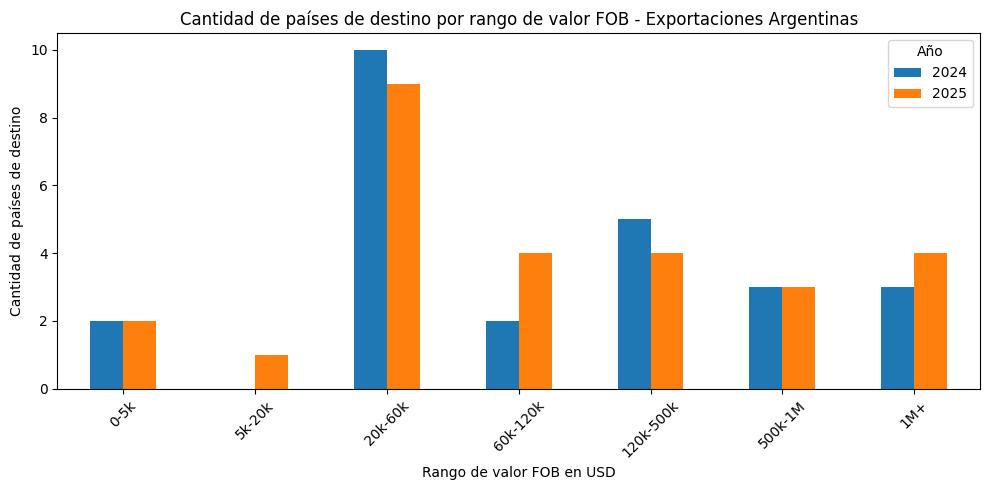

In [ ]:
df_expo_arg_temp = df_expo_arg.copy()
df_expo_arg_temp['Año'] = pd.to_datetime(df_expo_arg_temp['Fecha']).dt.year.astype(str)

valor_por_destino_anio = df_expo_arg_temp.groupby(['País de Destino', 'Año'])['U$S FOB'].sum().reset_index()

# Rangos más chicos, ya que acá cada fila es una operación individual, no un país-año agregado a nivel mundial
bins_arg = [0, 5000, 20000, 60000, 120000, 500000, 1_000_000, np.inf]
labels_arg = ['0-5k', '5k-20k', '20k-60k', '60k-120k', '120k-500k', '500k-1M', '1M+']

valor_por_destino_anio['rango'] = pd.cut(valor_por_destino_anio['U$S FOB'], bins=bins_arg, labels=labels_arg)

conteo_arg = valor_por_destino_anio.groupby(['rango', 'Año'], observed=True).size().unstack(fill_value=0)

conteo_arg.plot(kind='bar', figsize=(10,5))
plt.title('Cantidad de países de destino por rango de valor FOB - Exportaciones Argentinas')
plt.xlabel('Rango de valor FOB en USD')
plt.ylabel('Cantidad de países de destino')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Año')
plt.tight_layout()
plt.show()

Nuevamente se observa una importante agrupación de los daos hacia la izquierda, no siguiendo una distribución normal.

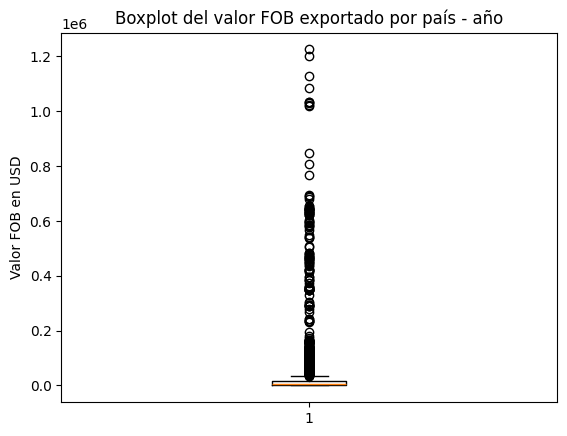

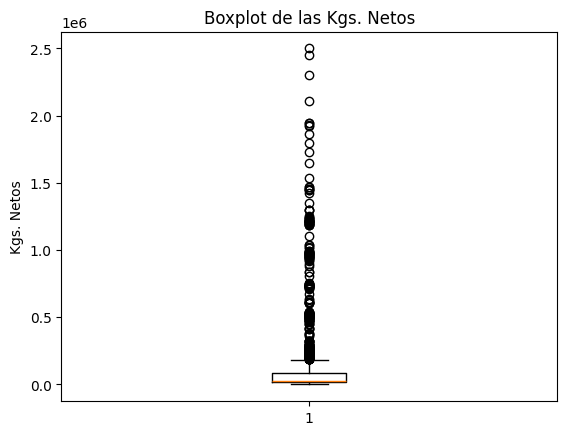

In [ ]:
#Boxplot de variables numéricas

plt.boxplot(df_expo_arg['U$S FOB'])
plt.title('Boxplot del valor FOB exportado por país - año')
plt.ylabel('Valor FOB en USD')
plt.show()

plt.boxplot(df_expo_arg['Kgs. Netos'])
plt.title('Boxplot de las Kgs. Netos')
plt.ylabel('Kgs. Netos')
plt.show()

<Axes: xlabel='Kgs. Netos'>

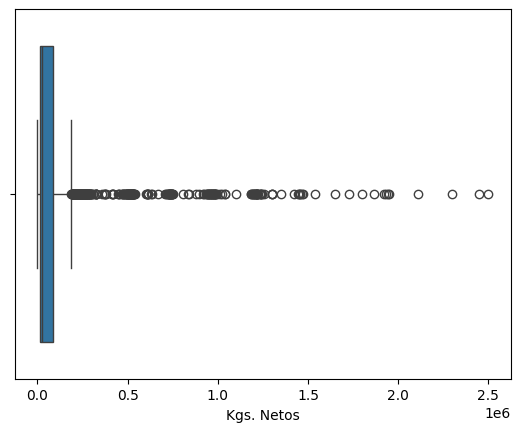

In [ ]:
#Otra forma de visualizar el boxplot capaz se ve mejor
sns.boxplot(x=df_expo_arg['Kgs. Netos'])

Es necesario hacer una mejor interpretación pero basicamente se ve aplastado porque aún no se ha realizado un preprocesamiento de los datos.

Estos resultados nos indican que estamos mezclando envíos muy grandes, con pesos muy altos y envíos más pequeños, provocando muchos outliers.

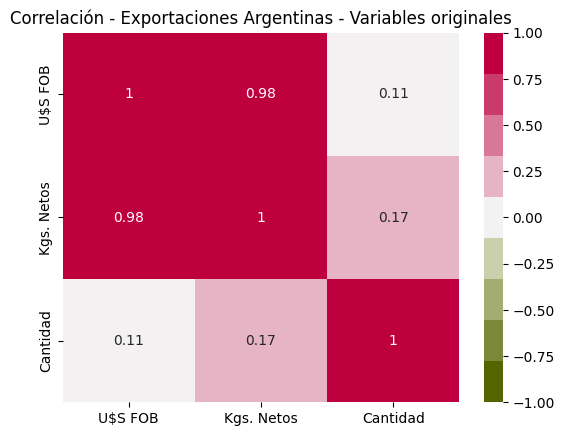

In [ ]:
#Correlación entre variables numéricas originales
#Esta correlación se realizó unicamente con los datos originales,
#sin procesar
sns.heatmap(df_expo_arg[['U$S FOB', 'Kgs. Netos','Cantidad']].corr(), annot=True, cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Exportaciones Argentinas - Variables originales')
plt.show()

Text(0.5, 1.0, 'Scatter Plot of U$S FOB vs Kgs. Netos')

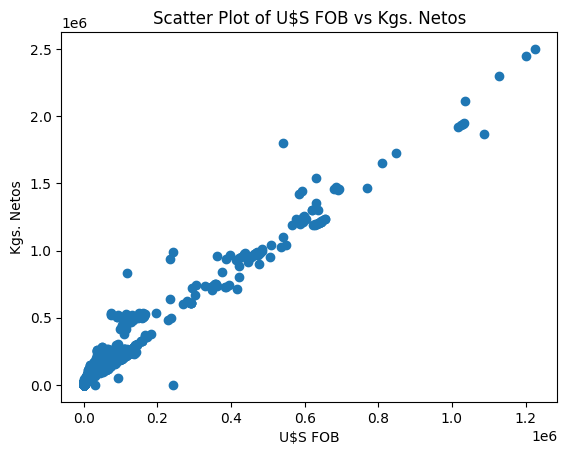

In [ ]:
plt.scatter(df_expo_arg['U$S FOB'], df_expo_arg['Kgs. Netos'])
plt.xlabel('U$S FOB')
plt.ylabel('Kgs. Netos')
plt.title('Scatter Plot of U$S FOB vs Kgs. Netos')


Análisis de la correlación: en este caso si se observa una importante correlación positiva entre los Kgs netos y el valor FOB. Esto es esperable ya que a mayor cantidad de kg exportados, mayor será el precio final FOB.

# 3.4 Importaciones detalladas por Empresa

In [ ]:
#Tipos de datos y cantidad de registros
df_impo_empresa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1307 entries, 0 to 1306
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NCM                 1307 non-null   object 
 1   AÑO                 1307 non-null   object 
 2   País de Empresa     1307 non-null   object 
 3   Empresa             1307 non-null   object 
 4   Operaciones         1307 non-null   int64  
 5   Valor U$S           1307 non-null   float64
 6   Kilos               1307 non-null   float64
 7   Socios Comerciales  1307 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 81.8+ KB


In [ ]:
#Estadísticas descriptivas
df_impo_empresa.describe()

,Operaciones,Valor U$S,Kilos
count,1307.000000,1.307000e+03,1.307000e+03
mean,10.035195,1.421813e+05,1.565580e+05
std,46.356171,1.870696e+06,7.293032e+05
min,1.000000,0.000000e+00,0.000000e+00
25%,1.000000,1.037110e+03,6.000000e+00
50%,2.000000,7.080000e+03,1.188400e+04
75%,6.000000,3.521629e+04,7.949085e+04
max,1118.000000,6.508686e+07,1.961591e+07


In [ ]:
#Valores faltantes
df_impo_empresa.isnull().sum()

,0
NCM,0
AÑO,0
País de Empresa,0
Empresa,0
Operaciones,0
Valor U$S,0
Kilos,0
Socios Comerciales,0


In [ ]:
print('Cantidad de países importadores:', df_impo_empresa['País de Empresa'].nunique())
df_impo_empresa['AÑO'].value_counts()

Cantidad de países importadores: 62


,count
AÑO,
2025,706
2024,601


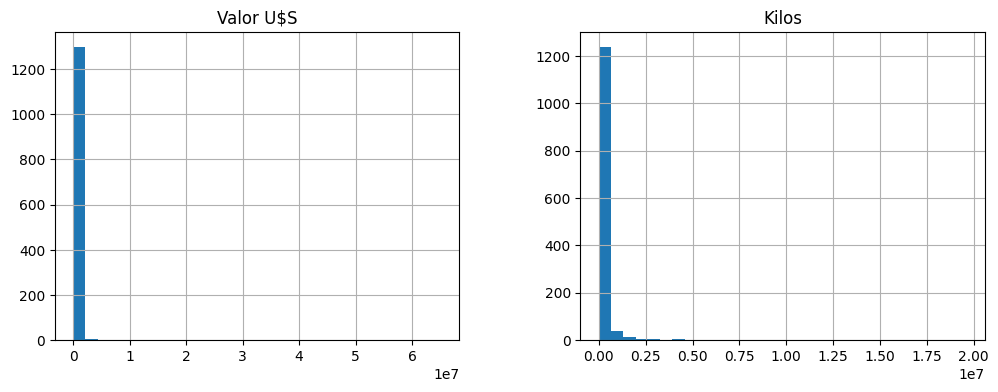

In [ ]:
#Histograma de variables numéricas
df_impo_empresa[['Valor U$S', 'Kilos']].hist(bins=30, figsize=(12,4))
plt.show()

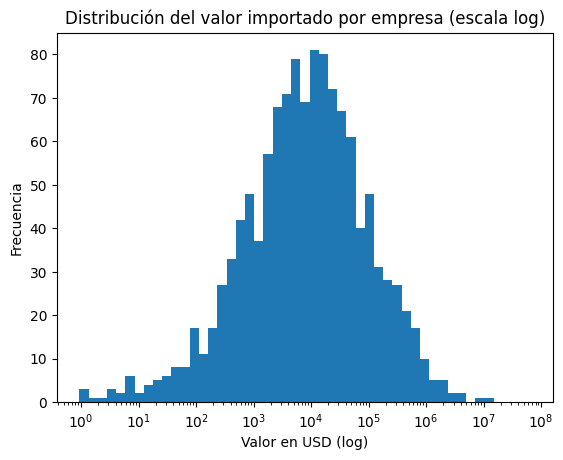

In [ ]:
valores_impo_empresa = df_impo_empresa[df_impo_empresa['Valor U$S'] > 0]['Valor U$S']
bins_log_impo_empresa = np.logspace(np.log10(valores_impo_empresa.min()), np.log10(valores_impo_empresa.max()), 50)

plt.hist(valores_impo_empresa, bins=bins_log_impo_empresa)
plt.xscale('log')
plt.title('Distribución del valor importado por empresa (escala log)')
plt.xlabel('Valor en USD (log)')
plt.ylabel('Frecuencia')
plt.show()

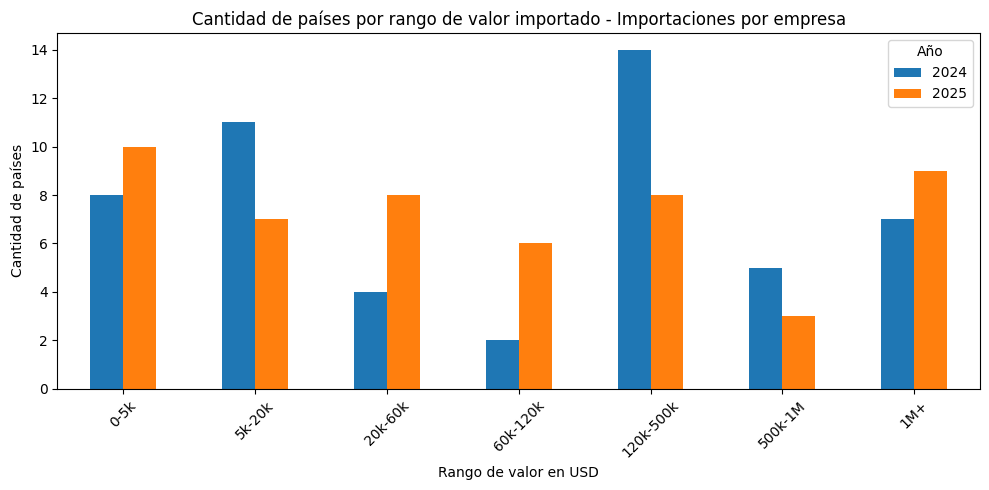

In [ ]:
valor_por_pais_anio_empresa = df_impo_empresa.groupby(['País de Empresa', 'AÑO'])['Valor U$S'].sum().reset_index()

bins_empresa = [0, 5000, 20000, 60000, 120000, 500000, 1_000_000, np.inf]
labels_empresa = ['0-5k', '5k-20k', '20k-60k', '60k-120k', '120k-500k', '500k-1M', '1M+']

valor_por_pais_anio_empresa['rango'] = pd.cut(valor_por_pais_anio_empresa['Valor U$S'], bins=bins_empresa, labels=labels_empresa)

conteo_empresa = valor_por_pais_anio_empresa.groupby(['rango', 'AÑO'], observed=True).size().unstack(fill_value=0)

conteo_empresa.plot(kind='bar', figsize=(10,5))
plt.title('Cantidad de países por rango de valor importado - Importaciones por empresa')
plt.xlabel('Rango de valor en USD')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend(title='Año')
plt.tight_layout()
plt.show()

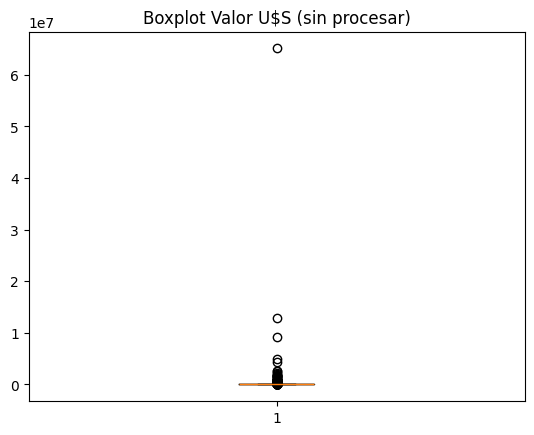

In [ ]:
#Boxplot del valor importado
plt.boxplot(df_impo_empresa['Valor U$S'])
plt.title('Boxplot Valor U$S (sin procesar)')
plt.show()

**Usar este recuadro para explicar todo lo observado hasta aca de este df**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

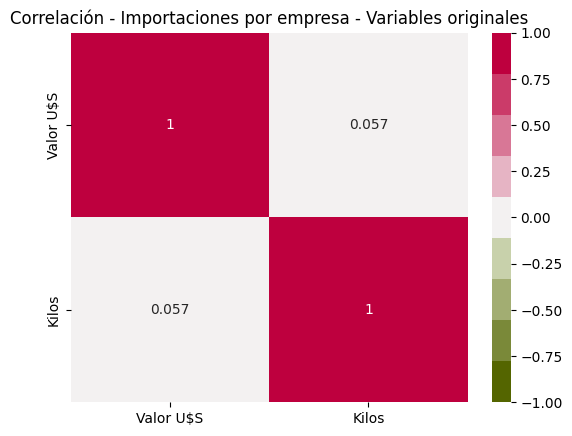

In [ ]:
#Correlación entre variables numéricas

sns.heatmap(df_impo_empresa[['Valor U$S', 'Kilos']].corr(), annot=True,
            cmap=palette, vmin=-1, vmax=1)
plt.title('Correlación - Importaciones por empresa - Variables originales')
plt

**Escribir en este cuadro conclusiones de la correlación**

--------------------------------------------------------------------------------
# 4. Análisis Exporatorio del MERCADO MUNDIAL
-------------------------------------------------------------------------------
A continuación se realizará un análisis a nivel del mercado con énfasis en el posicionamiento de Argentina en el mismo, para responder las siguientes preguntas:

* 4.1. ¿Qué lugar ocupa Argentina entre los exportadores?
* 4.2. ¿Cómo exporta Argentina? ¿Qué provincias exportan? Qué empresas lideran?¿Qué aduanas participan?
* 4.3.¿Hacia dónde exporta Argentina? ¿Cuántos mercados atiende?
* 4.4. ¿Qué porcentaje representan los principales compradores? ¿Argentina depende de pocos compradores?
* 4.5. ¿Los principales compradores mundiales son clientes de Argentina? ¿Hay mercados grandes donde Argentina casi no participa?


Las variables a utilizar serán las originales, aún sin el preprocesamiento que se aplicará para realizar los modelos de regresión lineal, ya que para este punto aún no son necesarios.

El objetivo de este Análisis Exploratorio del Mercado es identificar en qué puntos el modelo de regresión lineal podría beneficiar a Argentina


#4.1 ¿Qué lugar ocupa Argentina entre los exportadores?

Para determinar que lugar ocupa argentina es necesario primero saber el tamaño total del mercado exportador, es decir, saber la cantidad total de dólares que produce el mercado de exportación. De esa forma se podrá determinar cuales son los principaes exportadores mundiales.

In [ ]:
#Tamaño total del mercado exportador: suma total del FOBvalue en U$D
total_mercado_exportacion = df_expo_mundo['fobvalue'].sum()
print('Tamaño total del mercado de exportación:', total_mercado_exportacion)

Tamaño total del mercado de exportación: 5497329806.609


In [ ]:
#Principales exportadores mundiales

#Para realizar un ranking de los principales exportadores se tendrá en cuenta
#la variable reportDesc que determina el país de donde proviene la exportación y
#su correspondiente fobvalue, de forma que se sumen todas las exportaciones provenientes
#del mismo país

ranking_expo_mundo = df_expo_mundo.groupby('reporterDesc')['fobvalue'].sum().sort_values(ascending=False)

#Para mejorar la observación se obtiene el porcentaje de exportación, para lo cual
#se calculó previamente el tamaño total del mercado de exportación:

participacion_expo_mundo = (ranking_expo_mundo/total_mercado_exportacion)*100

#Para visualizar el resultado:

top10_expo_mundo = participacion_expo_mundo.head(10)
print(top10_expo_mundo)



reporterDesc
USA             47.009051
Australia       17.693999
Spain            8.956062
Canada           7.792044
Italy            2.683684
Netherlands      2.328636
Argentina        2.078118
France           1.808794
Romania          1.696407
South Africa     1.509253
Name: fobvalue, dtype: float64


Text(0, 0.5, 'País')

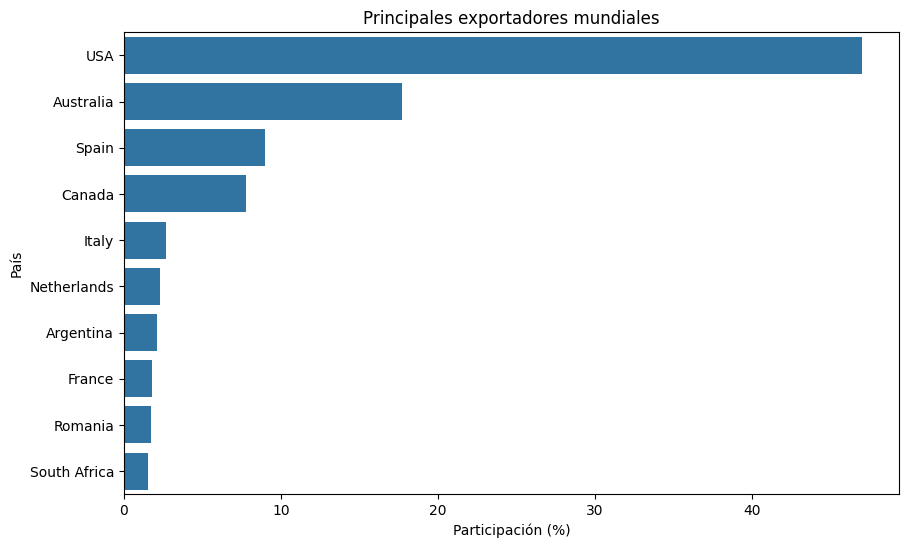

In [ ]:
#Para una mejor visualización de los resultados: gráfico de barras

plt.figure(figsize=(10,6))
sns.barplot(x=top10_expo_mundo.values, y=top10_expo_mundo.index)
plt.title('Principales exportadores mundiales')
plt.xlabel('Participación (%)')
plt.ylabel('País')

Obtenido el ranking, es posible visualizar específicamente a argentina, realizando una pequeña modificación en el gráfico:

/tmp/ipykernel_1135/2950045894.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette=colores)


Text(0, 0.5, 'País')

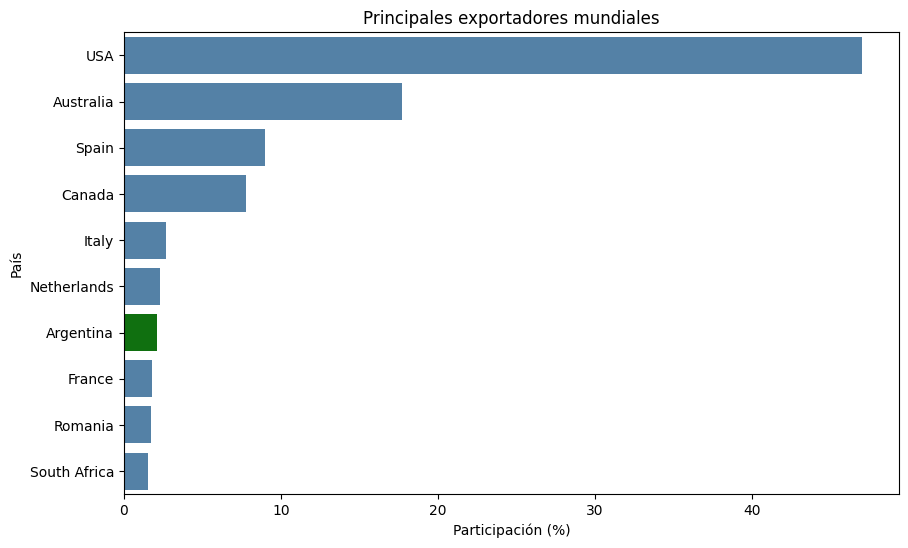

In [ ]:
top10 = participacion_expo_mundo.head(10)
colores = ['green' if pais == 'Argentina' else 'steelblue' for pais in top10.index]

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index, palette=colores)
plt.title('Principales exportadores mundiales')
plt.xlabel('Participación (%)')
plt.ylabel('País')

Con este gráfico se observa facilmente que Argentina ocupa el sexto lugar en el mercado mundial. agregar mayor cantidad de particiones en el porcentaje de participacion

#4.2. ¿Cómo exporta Argentina? ¿Qué provincias exportan? ¿Qué empresas lideran? ¿Qué aduanas participan?

Para determinar cómo exporta argentina, se utilizará el df de exportaciones argentinas con el detalle de las provincias exportadras y las aduanas participantes.

In [ ]:
#Valor FOB total exportado por argentina:

FOB_total_argentina = df_expo_arg['U$S FOB'].sum()
print('Valor FOB total exportado por Argentina:', FOB_total_argentina)

Valor FOB total exportado por Argentina: 114240998.05000001


In [ ]:
Provincia_expo = df_expo_arg.groupby('Localidad')['U$S FOB'].sum().sort_values(ascending = False)
Participacion_provincia = (Provincia_expo/FOB_total_argentina*100)
print(Participacion_provincia)



Localidad
CIUDAD AUTONOMA    85.667622
SAN LUIS            4.809134
POZO DEL MOLLE      2.823752
VIEDMA              2.798416
CORDOBA             2.765452
LUQUE-CORDOBA       0.214894
VILLA MARIA-COR     0.131714
BUENOS AIRES        0.123145
SANTIAGO DEL ES     0.116356
TRANSITO            0.095720
CIPOLLETTI          0.091540
SAN LUISÃ¿          0.083381
MAYOR BURATOVIC     0.055870
VILLA ANGELA-CH     0.043067
FUNES-SANTA FE      0.025945
No disponible       0.024030
SAN JUAN-SAN JU     0.021746
MESON DE FIERRO     0.019096
SANTA FE            0.017358
RIO CUARTO          0.013132
CHARATA             0.011817
RIO NEGRO           0.011555
FORMOSA             0.008003
CERRO AZUL-MISI     0.007838
ARGUELLO-CORDOB     0.006863
9 DE JULIO-BUEN     0.004802
SAN SALVADOR DE     0.004289
TORTUGUITAS         0.002626
FORMOSA-FORMOSA     0.000836
Name: U$S FOB, dtype: float64


In [ ]:
top5_provincias = Participacion_provincia.head(5)
print(top5_provincias)

Localidad
CIUDAD AUTONOMA    85.667622
SAN LUIS            4.809134
POZO DEL MOLLE      2.823752
VIEDMA              2.798416
CORDOBA             2.765452
Name: U$S FOB, dtype: float64


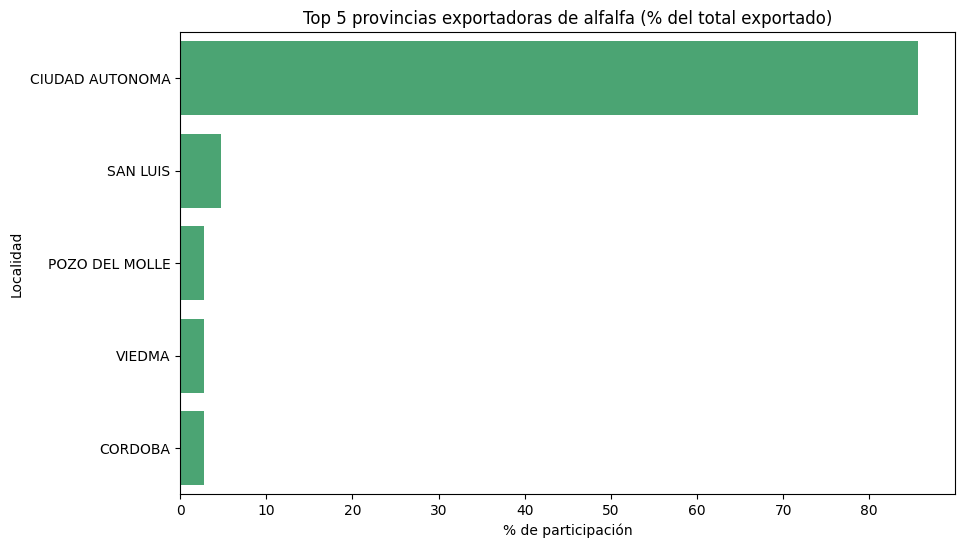

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top5_provincias.values, y=top5_provincias.index, color='mediumseagreen')
plt.title('Top 5 provincias exportadoras de alfalfa (% del total exportado)')
plt.xlabel('% de participación')
plt.show()

In [ ]:
#Empresas exportadoras

Empresa_expo = df_expo_arg.groupby('Exportador')['U$S FOB'].sum().sort_values(ascending = False)
Participacion_empresa = (Empresa_expo/FOB_total_argentina*100)

#Para observar las primeras 10 empresas exportadoras:

Top10_exportadores_arg = Participacion_empresa.head(10)
print(Top10_exportadores_arg)

Exportador
FONDOMONTE EL DESCANSO SA                   81.880929
LA CHITA SRL                                 4.809134
BOLLATTI JORGE LUIS                          2.823752
ALFALFA Y FORRAJE DE LA PATAGONIA S.A.       2.798416
COMPAÑIA ARGENTINA DE ALFALFAS Y FORRAJE     1.873172
MEGA ALFALFA ARGENTINA S.A.                  1.665296
DANIOTTI JULIO CESAR                         1.263747
PRAGA SRL                                    0.783409
OLOCCO GERMAN JULIO                          0.668314
No disponible                                0.225740
Name: U$S FOB, dtype: float64


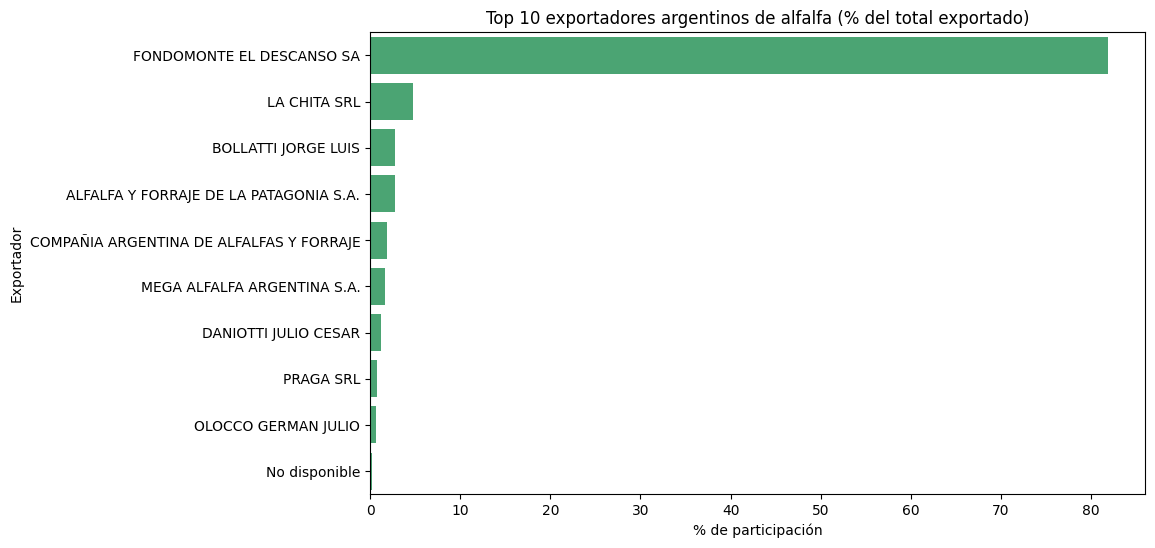

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=Top10_exportadores_arg.values, y=Top10_exportadores_arg.index, color='mediumseagreen')
plt.title('Top 10 exportadores argentinos de alfalfa (% del total exportado)')
plt.xlabel('% de participación')
plt.show()

In [ ]:
#Aduanas por las que se exporta

aduanas = df_expo_arg.groupby('Aduana')['U$S FOB'].sum().sort_values(ascending=False)
participacion_aduanas = (aduanas/FOB_total_argentina*100)
participacion_aduanas.head(10)

,U$S FOB
Aduana,
CORDOBA,81.769634
SAN LUIS,6.680607
BAHIA BLANCA,4.763046
SANTIAGO DEL ESTERO,2.510001
BS.AS. (CAPITAL),1.591154
PASO DE LOS LIBRES,1.183191
SANTO TOME,0.683130
SAN JAVIER,0.417631
GENERAL DEHEZA,0.144846


Text(0.5, 1.0, 'Aduanas por las que exporta Argentina (% del total exportado)')

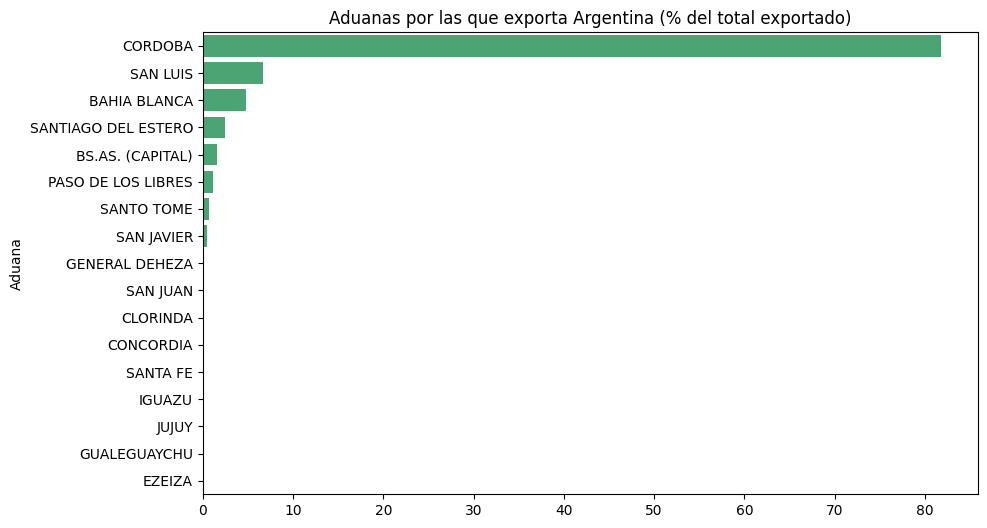

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=participacion_aduanas.values, y=participacion_aduanas.index, color='mediumseagreen')
plt.title('Aduanas por las que exporta Argentina (% del total exportado)')

Conclusiones:

#4.3 ¿Hacia dónde exporta Argentina? ¿Cuántos mercados atiende?

Saber los mercados a los que Argentina atiende y compararlos con las importaciones mundiales permitirá determinar nuevas oportunidades para Argentina y posicionarse aún más en el mercado mundial.

In [ ]:
destinos_expo_arg = df_expo_arg.groupby('País de Destino')['U$S FOB'].sum().sort_values(ascending=False)
participacion_destinos_expo = (destinos_expo_arg/FOB_total_argentina*100)

top10_destinos_expo_arg = participacion_destinos_expo.head(10)
print(top10_destinos_expo_arg)

print('Cantidad de mercados distintos atendidos:', df_expo_arg['País de Destino'].nunique())
print('Los primeros 3 destinos concentran:', round(participacion_destinos_expo.head(3).sum(),2), '% del total exportado')

País de Destino
Arabia Saudi              85.264271
Emiratos Árabes Unidos     3.328969
Brasil                     2.749827
Omán                       1.903514
Colombia                   1.678240
Chile                      1.356214
China                      0.805724
Panamá                     0.693883
Tailandia                  0.451873
República Dominicana       0.332700
Name: U$S FOB, dtype: float64
Cantidad de mercados distintos atendidos: 29
Los primeros 3 destinos concentran: 91.34 % del total exportado


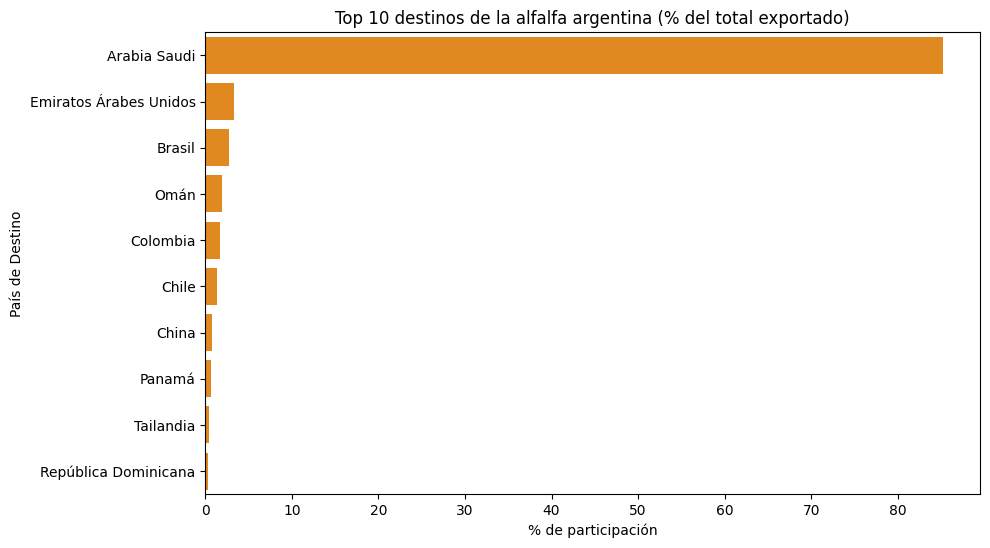

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top10_destinos_expo_arg.values, y=top10_destinos_expo_arg.index, color='darkorange')
plt.title('Top 10 destinos de la alfalfa argentina (% del total exportado)')
plt.xlabel('% de participación')
plt.show()

###**Conclusiones observadas sobre la posición de Argentina en el mercado mundial y su forma de exportación a nivel Nacional**

# 4.5. ¿Los principales compradores mundiales son clientes de Argentina? ¿Hay mercados grandes donde Argentina casi no participa?¿Qué mercados representan oportundiades comerciales para Argentina?**

Utilizando la información disponible en el df_impo_empresa se determinará el ranking mundial de importadores y se lo comparará con los destinos de exportación argentina, para determinar si los grandes importadores mundiales son abastecidos por Argentina o pueden existir nuevas oportunidades comerciales para nuestro país.

Nota de aclaración: se usa el df_impo_empresa ya que este tiene un apartado de socios comerciales, es decir, dice que pais de origen es cada importacion, desde donde compra cada empresa importadora. Esta fuente es la que nos permite saber si le compran a Argentina o no

In [ ]:
print(df_impo_empresa.sample(n=30))

         NCM   AÑO      País de Empresa  \
1235  1214.9  2025               Lesoto   
1056  1214.9  2025         Países Bajos   
831   1214.9  2024           Kazajistán   
517   1214.1  2025               Lesoto   
682   1214.9  2024               Lesoto   
433   1214.1  2025               Lesoto   
777   1214.9  2024               Lesoto   
1163  1214.9  2025       Estados Unidos   
1267  1214.9  2025              Somalia   
647   1214.9  2024  Camboya (Campuchea)   
724   1214.9  2024              Vietnam   
801   1214.9  2024              Vietnam   
138   1214.1  2024              Curazao   
1018  1214.9  2025               México   
1168  1214.9  2025       Estados Unidos   
415   1214.1  2025               Panamá   
394   1214.1  2025           Tajikistán   
101   1214.1  2024            Filipinas   
31    1214.1  2024               Lesoto   
151   1214.1  2024               Lesoto   
83    1214.1  2024               Lesoto   
1072  1214.9  2025               México   
330   1214.

In [ ]:
total_impo_empresa = df_impo_empresa['Valor U$S'].sum()
ranking_impo_empresa = df_impo_empresa.groupby('País de Empresa')['Valor U$S'].sum().sort_values(ascending=False)
participacion_impo_empresa = (ranking_impo_empresa / total_impo_empresa * 100).round(2)

top10_importadores_empresa = participacion_impo_empresa.head(10)
print(top10_importadores_empresa)

# Cuanto le exporta hoy Argentina a cada uno de esos top 10 importadores (segun nuestra propia hoja de exportaciones)
exportacion_por_destino = df_expo_arg.groupby('País de Destino')['U$S FOB'].sum()

tabla_oportunidades = []
for pais in top10_importadores_empresa.index:
    valor_exportado_arg = exportacion_por_destino.get(pais, 0)
    tabla_oportunidades.append([pais, top10_importadores_empresa[pais], valor_exportado_arg])

tabla_oportunidades = pd.DataFrame(
    tabla_oportunidades,
    columns=['Pais', 'Participacion_mundial_%', 'Exportacion_Argentina_USD']
)
tabla_oportunidades

País de Empresa
Vietnam                   59.51
Lesoto                    15.98
Estados Unidos             5.31
Filipinas                  4.98
Colombia                   2.60
México                     2.48
Japón                      1.37
Emiratos Árabes Unidos     1.22
Panamá                     1.08
Puerto Rico                0.88
Name: Valor U$S, dtype: float64


,Pais,Participacion_mundial_%,Exportacion_Argentina_USD
0,Vietnam,59.51,108869.48
1,Lesoto,15.98,0.00
2,Estados Unidos,5.31,10165.80
3,Filipinas,4.98,0.00
4,Colombia,2.60,1917238.40
5,México,2.48,0.00
6,Japón,1.37,0.00
7,Emiratos Árabes Unidos,1.22,3803047.33
8,Panamá,1.08,792698.40
9,Puerto Rico,0.88,4160.00


In [ ]:
#Primero es necesario determinar el total importado en U$D y el ranking de empresas
#importadoras, para después determinar el país de origen de esas empresas

total_impo_mundial = df_impo_empresa['Valor U$S'].sum()
ranking_impo_empresa = df_impo_empresa.groupby('País de Empresa')['Valor U$S'].sum().sort_values(ascending=False)
participacion_impo_empresa = (ranking_impo_empresa / total_impo_mundial * 100).round(2)

#Top 10 importadires:

top10_importadores_empresa = participacion_impo_empresa.head(10)
print(top10_importadores_empresa)

#Luego se crea la lista con las empresas importadoras segun el ranking, en base a
#sus países, ya que fueron agrupadas previamente con esa variable

exportacion_por_destino = df_expo_arg.groupby('País de Destino')['U$S FOB'].sum()

tabla_oportunidades_list = []
for pais in top10_importadores_empresa.index:
  valor_exportado_arg = exportacion_por_destino.get(pais,0) #.get (pais,0)permite que el código
  #devuelva el valor cero si Argentina nunca le importó, para así identificar aquellos
  #posibles nuevos mercados. Sin esta parte de la función el bucle los pasaría por alto
  tabla_oportunidades_list.append([pais, top10_importadores_empresa[pais], valor_exportado_arg])
  # .append agrega a la tabla de oportunidades una fila donde se resuma el nombre
  #del país, su porcentaje de participación en el ranking y cuanto le exportó argentina, si
  #es que le exportó.

tabla_oportunidades = pd.DataFrame(
    tabla_oportunidades_list,
    columns=['Pais', 'Participacion_mundial_%', 'Exportacion_Argentina_USD']
)
tabla_oportunidades

País de Empresa
Vietnam                   59.51
Lesoto                    15.98
Estados Unidos             5.31
Filipinas                  4.98
Colombia                   2.60
México                     2.48
Japón                      1.37
Emiratos Árabes Unidos     1.22
Panamá                     1.08
Puerto Rico                0.88
Name: Valor U$S, dtype: float64


,Pais,Participacion_mundial_%,Exportacion_Argentina_USD
0,Vietnam,59.51,108869.48
1,Lesoto,15.98,0.00
2,Estados Unidos,5.31,10165.80
3,Filipinas,4.98,0.00
4,Colombia,2.60,1917238.40
5,México,2.48,0.00
6,Japón,1.37,0.00
7,Emiratos Árabes Unidos,1.22,3803047.33
8,Panamá,1.08,792698.40
9,Puerto Rico,0.88,4160.00


En este caso se obtiene el ranking, pero como se ve en la primera línea de código de este apartado, hay columnas cuyo socio comercial son varios países, dentro de los cuales está Argentina. Con el código realizado solamente se ve aquellos países a los que sólo Argentina le vende y se esta perdiendo la información respecto a países con más de un socio comercial. Por esta razón se realizará una verificación extra para ver si hay resultados diferentes teniedo en cuenta aquellos países con más de un socio comercial.

In [ ]:
# Verificacion: quienes declaran comprarle a Argentina, segun la propia fuente importadora
# (usamos .str.contains porque la columna a veces trae varios paises de origen juntos en una misma celda,
# por ejemplo "Chile,Argentina", y con un filtro de igualdad exacta esos casos quedarian afuera)

compras_a_argentina = df_impo_empresa[df_impo_empresa['Socios Comerciales'].str.contains('Argentina')]
compradores_de_argentina = compras_a_argentina.groupby('País de Empresa')['Valor U$S'].sum()

compradores_de_argentina

# Se agrega esa verificacion como una columna mas en la tabla de oportunidades,
# para comparar "lo que dice Argentina que exporta" contra "lo que dice el importador que importa"
tabla_oportunidades['Compra_a_Argentina_segun_importador_USD'] = tabla_oportunidades['Pais'].map(compradores_de_argentina).fillna(0)

#.map es una función que ve en la columna país y busca la correspondencia entre exportaciones argentinas y
#compradores mundiales, es decir los importadores. Aquellos compradores que no aparecen en compradores de argentina
#la función fillna(0)les pone valor cero.

tabla_oportunidades

,Pais,Participacion_mundial_%,Exportacion_Argentina_USD,Compra_a_Argentina_segun_importador_USD
0,Vietnam,59.51,108869.48,366275.27
1,Lesoto,15.98,0.00,0.00
2,Estados Unidos,5.31,10165.80,0.00
3,Filipinas,4.98,0.00,0.00
4,Colombia,2.60,1917238.40,2009420.11
5,México,2.48,0.00,0.00
6,Japón,1.37,0.00,0.00
7,Emiratos Árabes Unidos,1.22,3803047.33,0.00
8,Panamá,1.08,792698.40,1890844.81
9,Puerto Rico,0.88,4160.00,0.00


Para observar gráficamente la comparación, se pueden utilizar gráficos de barra sencillos:

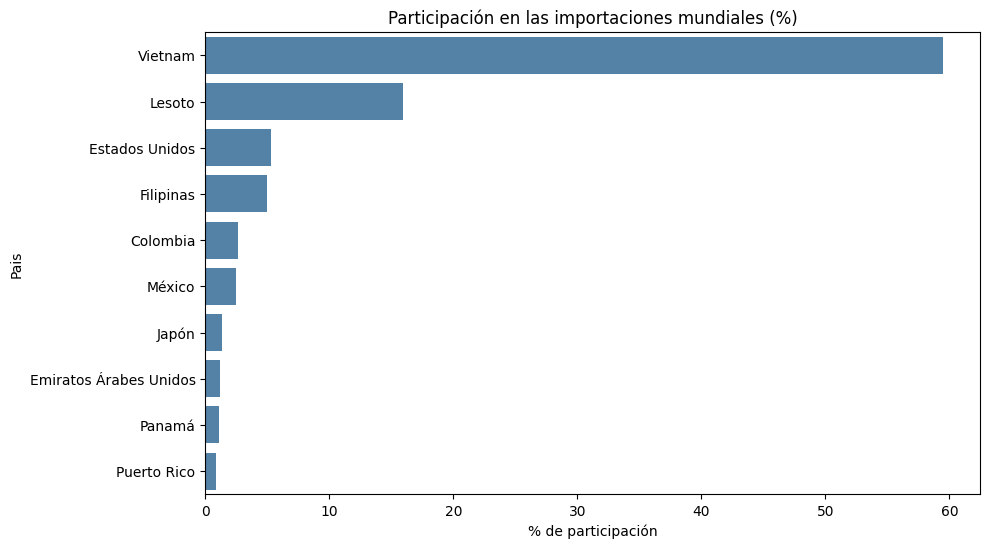

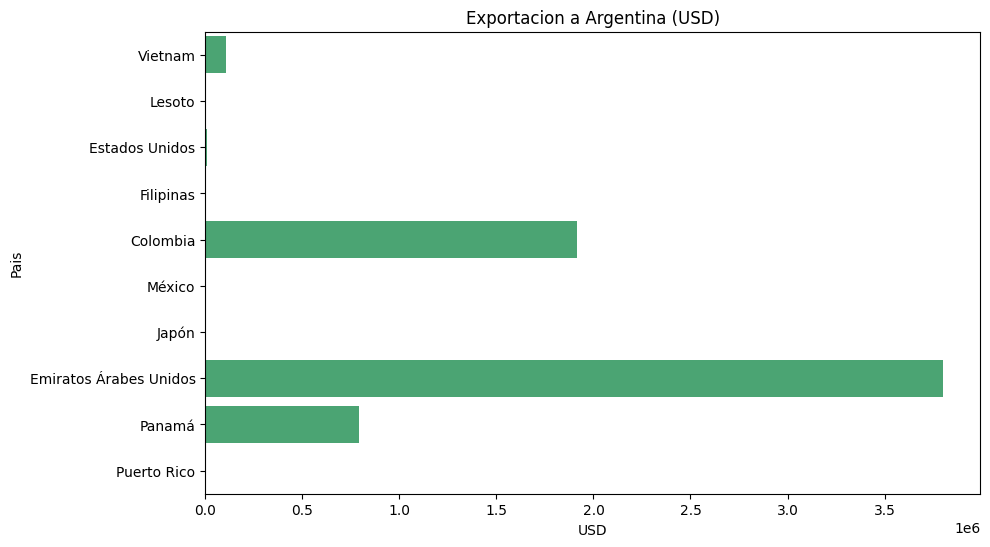

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=tabla_oportunidades['Participacion_mundial_%'], y=tabla_oportunidades['Pais'], color='steelblue')
plt.title('Participación en las importaciones mundiales (%)')
plt.xlabel('% de participación')
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=tabla_oportunidades['Exportacion_Argentina_USD'], y=tabla_oportunidades['Pais'], color='mediumseagreen')
plt.title('Exportacion a Argentina (USD)')
plt.xlabel('USD')
plt.show()

Con esto claramente se observa que argentina exporta mucho a ciertos países pero se está perdiendo a los grandes importadores mundiales. En base a esto **hacer un análisis sobre que mercados representan oportundiades comerciales para Argentina**.

--------------------------------------------------------------------------------
#5. Construcción de un modelo de regresión
-------------------------------------------------------------------------------
Como última parte del análisis se buscará crear un modelo que permita predecir el valor de la alfalfa.

Crear este modelo permitiría poder cotizar correctamente una exportación de alfalfa teniendo en cuenta diferentes condiciones de dicha operación, como destino, condición de venta, volumen y época del año. Además conocer las variables que realmente influyen en el precio final de exportación, permitirían a las empresas exportadoras argentinas buscar nuevas opciones para poder mejorar sus precios y ser más competitivos, buscando negociar mejores condiciones de venta.

Así mismo, con dicho modelo se buscará testear con rigor estadístico si la estacionalidad efectivamente influye en el precio (una hipótesis de partida del trabajo).

Para realizar este modelo, primero se llevará a cabo un preprocesamiento de los datos y posteriormente se probarán distintos modelos para comparar sus métricas y determinar cual es el mejor predictor.

#5.1 Preprocesamiento de los datos

Desde este momento se realizará el preprocesamiento de los datos que se utilizarán en el modelo de regresión, por lo cual solo se utilizará la hoja de exportaciones argentinas (df_expo_arg) para analizar en detalle las exportaciones argentinas.

El preprocesamiento se dividira en:

a. Creación de un valor confiable de precio por kg, para unificar el precio de grandes y pequeñas exportaciones.

b. Tratamiento de outliers por método IQR

c. Construcción de la variable estacionalidad, para determinar si el precio depende de la estación del año (relación con la época de siempra y cosecha)

d. Codificación de variables binarias



## a. Contrucción de una variable de precio confiable

La columna USD Unitario mezcla distintas unidades de medida (toneladas, kilogramos, unidades), por lo que no es comparable entre filas. La columna U$S FOB sí está en dólares de forma consistente, pero representa el valor total de cada operación, no el precio por kilo. Por eso construimos una nueva variable dividiendo el FOB por el peso neto en kilos.


In [ ]:
#Se crea una copia del df para no trabajar variables
#sobreescritas sobre el original, manteniendolos como
#independientes

df= df_expo_arg.copy()
df['precio_por_kg'] = df['U$S FOB'] / df['Kgs. Netos']

#Se eliminan las filas sin kgs netos válidos, es decir aquellas que tengan
#divisiones por cero o nulos

df=df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['precio_por_kg'])

df['precio_por_kg'].describe()

,precio_por_kg
count,2597.000000
mean,0.516603
std,9.356783
min,0.029750
25%,0.160000
50%,0.175000
75%,0.450000
max,410.000000


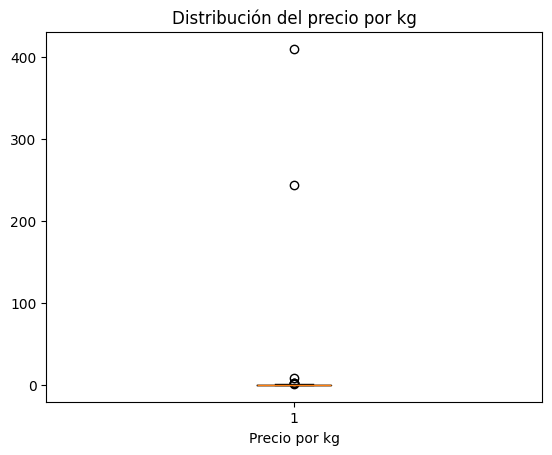

In [ ]:
plt.boxplot(df['precio_por_kg'])
plt.title('Distribución del precio por kg')
plt.xlabel('Precio por kg')
plt.ylabel('')
plt.show()

###**Conclusiones sobre la distribución del Precio Por Kg**:

El boxplot original muestra una distribución completamente aplastada contra el cero, con dos valores extremos aislados que llegan hasta 250 y más de 400. Esto genera una escala tan distorsionada que no permite visualizar correctamente cómo se distribuye la mayoría de los datos, ya que esos pocos casos extremos comprimen visualmente al resto de las observaciones en una franja mínima cerca de cero.

##b. Tratamiento de outliers por método IQR

In [ ]:
#Determinación de los percentiles:

percentile25 = df['precio_por_kg'].quantile(0.25)
percentile75 = df['precio_por_kg'].quantile(0.75)
iqr= percentile75-percentile25
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 *iqr

print('Límite inferior:', round(lower_limit,2))
print('Límite superior:', round(upper_limit,2))

print('Filas previo a eliminar outliers:', df.shape[0])
df= df[(df['precio_por_kg']>= lower_limit) & (df['precio_por_kg'] <= upper_limit)]
print('Filas despues de sacar outliers:', df.shape[0])

Límite inferior: -0.28
Límite superior: 0.88
Filas previo a eliminar outliers: 2597
Filas despues de sacar outliers: 2590


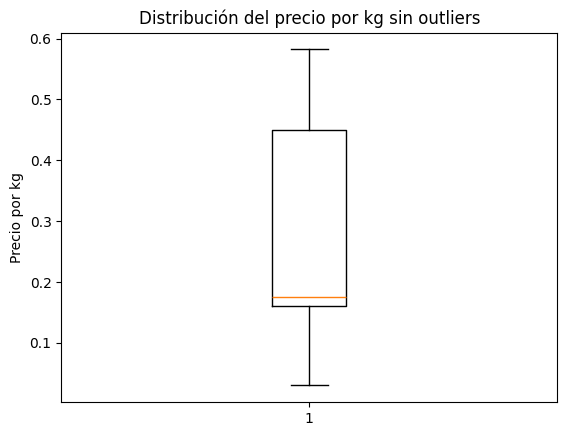

In [ ]:
plt.boxplot(df['precio_por_kg'])
plt.title('Distribución del precio por kg sin outliers')
plt.ylabel('Precio por kg')
plt.show()

###**COnclusiones sobre el Precio por Kg sin Outliers**:

Utilizando los percentiles 25 y 75, se calcularon los límites de corte: un límite inferior de -0.28 y un límite superior de 0.88. Aplicando este criterio, se identificaron y eliminaron 7 registros (de 2597 a 2590 filas), correspondientes a esos valores extremos que distorsionaban la distribución.

El boxplot muestra una distribución mucho más clara e interpretable: la mediana se ubica en torno a 0.17-0.18, con el 50% central de los datos (caja) entre aproximadamente 0.16 y 0.45, y bigotes que se extienden desde cerca de 0.03 hasta 0.58, sin outliers remanentes.

**Conclusión:**

El tratamiento de outliers resultó fundamental para poder trabajar correctamente con esta variable: los pocos valores extremos presentes originalmente (probablemente errores de carga, operaciones atípicas puntuales, o casos particulares no representativos del mercado) distorsionaban tanto la escala que impedían cualquier análisis o modelado confiable.

Al eliminar únicamente 7 registros de un total de 2597 (una proporción mínima de la muestra), se logró una distribución de precios mucho más representativa del comportamiento habitual del mercado, adecuada para ser utilizada como variable dependiente en los modelos de regresión.

## c. Contrucción de la variable estacionalidad

Para determinar la estacionalidad se utilizará un metodo sencillo de recategorización, para lo cual se le asignará a cada mes del año su estación correspondiente y se creará una nueva columna donde se indique dicha estación.

In [ ]:
#Selección de la variable tiempo:

df['Fecha'] = pd.to_datetime(df['Fecha'])
#con la funcion pd.to_datetime se convierte el dato en
#objetos de tipo datetime, se le cambia el formato a fecha

df['Mes'] = df['Fecha'].dt.month

#Extrae de las fechas unicamente el mes y crea una nueva
#variable donde solo se explicita el mes donde se realizó la venta

#Se asignan las estaciones a cada exportación en base a su mes:

estaciones = {
    12: 'Verano', 1: 'Verano', 2: 'Verano',
    3: 'Otoño', 4: 'Otoño', 5: 'Otoño',
    6: 'Invierno', 7: 'Invierno', 8: 'Invierno',
    9: 'Primavera', 10: 'Primavera', 11: 'Primavera'
}

df['Estacion'] = df['Mes'].map(estaciones)

df[['Fecha', 'Mes', 'Estacion']].head(10)

,Fecha,Mes,Estacion
0,2024-01-02,1,Verano
1,2024-01-02,1,Verano
2,2024-01-03,1,Verano
3,2024-01-05,1,Verano
4,2024-01-08,1,Verano
5,2024-01-09,1,Verano
6,2024-01-10,1,Verano
7,2024-01-11,1,Verano
8,2024-01-15,1,Verano
9,2024-01-15,1,Verano


In [ ]:
df['Estacion'].value_counts()

,count
Estacion,
Primavera,862
Verano,620
Invierno,605
Otoño,503


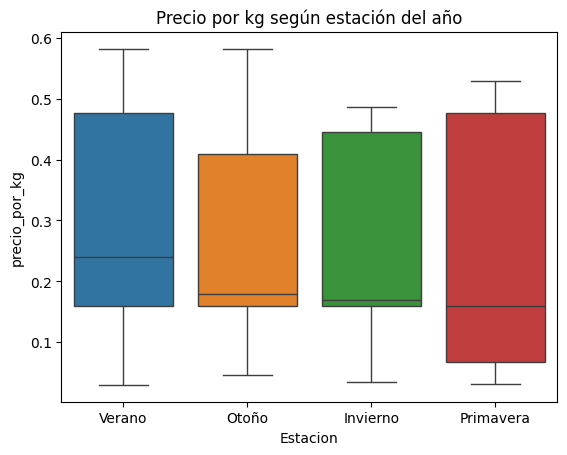

In [ ]:
sns.boxplot(x='Estacion', y='precio_por_kg', data=df, hue='Estacion')
plt.title('Precio por kg según estación del año')
plt.show()

###**Conclusiones parciales sobre la estacionalidad:**

* Las cuatro estaciones presentan una mediana similar (entre 0.16 y 0.24 aproximadamente), sin diferencias marcadas entre ellas.

* Verano muestra la mediana más alta (0.24), mientras que Primavera se ubica más baja (0.16), pero en todos los casos las cajas se superponen considerablemente entre sí.

* Todas las estaciones presentan una dispersión amplia y similar, sin que ninguna estación que se distinga claramente por concentrar precios más altos o más bajos de forma sistemática.

De forma puramente visual, no se observan grandes diferencias en el precio por kg según la estación del año.

## d. Codificación de variables binarias

Se convertiran a 0 y 1 las variables correspondientes a ES CÓRDOBA y ES CÚSTER para poder utilizar estas variables categóricas como numéricas en los modelos de regresión.

In [ ]:
df['ES_CORDOBA'] = df['ES CÓRDOBA?'].map({'SI': 1, 'NO': 0})
df['ES_CLUSTER'] = df['ES CLÚSTER?'].map({'SI': 1, 'NO': 0})
df[['ES CÓRDOBA?', 'ES_CORDOBA', 'ES CLÚSTER?', 'ES_CLUSTER']].head()

,ES CÓRDOBA?,ES_CORDOBA,ES CLÚSTER?,ES_CLUSTER
0,NO,0,NO,0
1,NO,0,NO,0
2,SI,1,NO,0
3,NO,0,NO,0
4,NO,0,NO,0


# 5.2 Análisis de Correlación

Se calculará a continuación la correlación entre todas las variables numéricas disponibles para observar a priori posibles variables que expliquen o ayuden a predecir el precio del kg de alfalfa.

In [ ]:
correlacion = ['precio_por_kg', 'Kgs. Netos', 'U$S FOB', 'Cantidad', 'ES_CORDOBA', 'ES_CLUSTER']
correlacion = df[correlacion].corr()
correlacion

,precio_por_kg,Kgs. Netos,U$S FOB,Cantidad,ES_CORDOBA,ES_CLUSTER
precio_por_kg,1.000000,0.348228,0.398223,0.014621,0.744621,0.742907
Kgs. Netos,0.348228,1.000000,0.981202,0.169306,0.237772,0.321163
U$S FOB,0.398223,0.981202,1.000000,0.109358,0.271184,0.364430
Cantidad,0.014621,0.169306,0.109358,1.000000,-0.054910,0.075909
ES_CORDOBA,0.744621,0.237772,0.271184,-0.054910,1.000000,0.573151
ES_CLUSTER,0.742907,0.321163,0.364430,0.075909,0.573151,1.000000


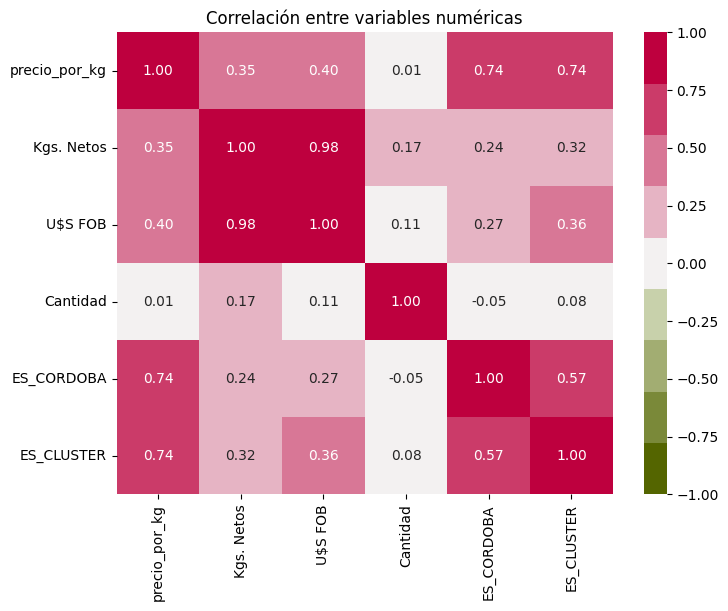

In [ ]:
palette = sns.diverging_palette(100, 5, s=100, l=40, n=9)
plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap= palette, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

###**Conclusiones de la correlacion:**

# 5.3 Preparación final de los datos para el modelo

Se utilizarán 3 de los modelos vistos en clase para observar cual de ellos se adecua mejor a los datos que se poseen.

En primer lugar se dividirá el dataset en datasetsde entrenamiento y prueba y posteriormente se aplicarán modelos de regresión lineal múltiple

#### Codificación de variables categóricas

Para evitar demasiadas categorías de países se utilizará la categoría "Otros" para países que son eventuales compradores, pudiendo hacer énfasis en los principales destinos comerciales

In [ ]:
top_destinos_expo = df['País de Destino'].value_counts().head(5).index #Indez contiene los nombres de los 5 países más frecuentes
df['Destino_agrupado'] = df['País de Destino'].where(df['País de Destino'].isin(top_destinos_expo), 'Otros')
df['Destino_agrupado'].value_counts()

#Las funciones where y isin crean un bucle donde se busca en todo el df
#los países que aparecen en el top 5 y se les mantiene su valor, si no aparecen
#se los codifica en la categoría de Otros


,count
Destino_agrupado,
Arabia Saudi,916
Brasil,761
Otros,432
Colombia,214
Chile,147
Panamá,120


A continuación se seleccionarán las variables a aplicar en el modelo y se transformarán con la fución pd.get_dummies de forma que las variables categóricas se transformen en numéricas y pueda aplicarse el modelo de regresión lineal multivariado.

In [ ]:
df_modelo = df[['precio_por_kg', 'Kgs. Netos', 'ES_CORDOBA', 'ES_CLUSTER',
                'Estacion', 'Destino_agrupado', 'Via Transporte', 'Condición de Venta']].copy()

df_modelo = pd.get_dummies(df_modelo, columns=['Estacion', 'Destino_agrupado', 'Via Transporte', 'Condición de Venta'], drop_first=True)
df_modelo.head()


,precio_por_kg,Kgs. Netos,ES_CORDOBA,ES_CLUSTER,Estacion_Otoño,Estacion_Primavera,Estacion_Verano,Destino_agrupado_Brasil,Destino_agrupado_Chile,Destino_agrupado_Colombia,Destino_agrupado_Otros,Destino_agrupado_Panamá,Via Transporte_CAMION,Via Transporte_FERROCARRIL,Condición de Venta_CIF,Condición de Venta_CIP,Condición de Venta_CPT,Condición de Venta_EXW,Condición de Venta_FCA,Condición de Venta_FOB
0,0.180,27000.0,0,0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False
1,0.180,27000.0,0,0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False
2,0.225,28000.0,1,0,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False
3,0.140,56004.0,0,0,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False
4,0.300,10000.0,0,0,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False


#5.4 División del Dataframe en Entrenamiento y Prueba

A continuación se realizará la división del dataset en test and train para entrenar y testear los modelos. Además se observará la distribución de ambos dataset con histogramas para corroborar que ambos datasets tengan una distribución de precios similar.

In [ ]:
X = df_modelo.drop('precio_por_kg', axis=1)
y = df_modelo['precio_por_kg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (1942, 19) | Test: (648, 19)


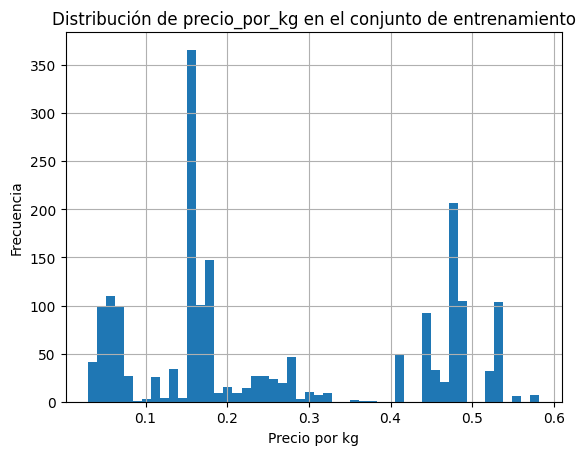

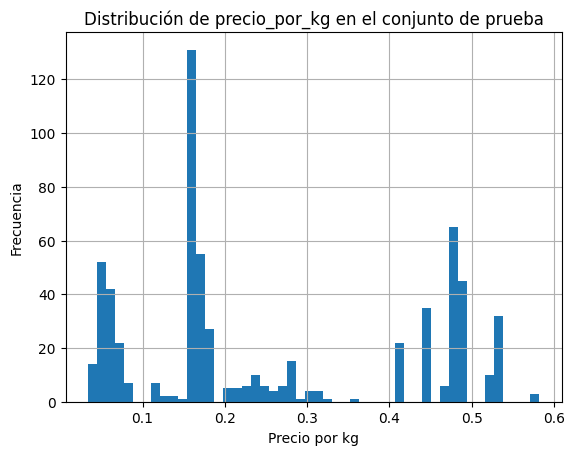

In [ ]:
y_train.hist(bins=50)
plt.title('Distribución de precio_por_kg en el conjunto de entrenamiento')
plt.xlabel('Precio por kg')
plt.ylabel('Frecuencia')
plt.show()

y_test.hist(bins=50)
plt.title('Distribución de precio_por_kg en el conjunto de prueba')
plt.xlabel('Precio por kg')
plt.ylabel('Frecuencia')
plt.show()

###**Interpretación de los Histogramas**

Ambas distribuciones muestran un **patrón multimodal (varios picos)**, en lugar de una única campana centrada en un valor. Se observan tres concentraciones principales de datos: alrededor de 0.05-0.06, 0.15-0.20 y 0.45-0.50, con pocos casos en los valores intermedios. Esto sugiere que **el precio por kg de la alfalfa no se distribuye de forma continua y homogénea**, sino que tiende a agruparse en rangos específicos — probablemente asociados a **combinaciones típicas de destino, condición de venta u otras variables categóricas que fijan rangos de precio relativamente estandarizados en el mercado.**

Lo más importante a destacar es que **ambos conjuntos (train y test) replican el mismo patrón de picos y valles**, en la misma ubicación y con proporciones similares entre sí. Esto confirma que el train_test_split generó una **partición representativa de los datos:** el conjunto de prueba no quedó sesgado hacia ningún rango de precio en particular. Esta es una condición necesaria para que las métricas de test reflejen fielmente la capacidad de generalización del modelo y no un artefacto de una mala división muestral.

# 5.5 Construcción de modelos de regresión.

###**Modelo con statsmodels**

Se realizará un primer modelo con el algoritmo statsmodels para ver la significancia estadística de las variables que se plantearon a priori en el modelo.

In [ ]:
X_train_const = sm.add_constant(X_train.astype(float))
olsmod = sm.OLS(y_train.astype(float), X_train_const).fit()
print(olsmod.summary())

                            OLS Regression Results                            
Dep. Variable:          precio_por_kg   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     1308.
Date:                Sat, 22 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:45:50   Log-Likelihood:                 3257.5
No. Observations:                1942   AIC:                            -6475.
Df Residuals:                    1922   BIC:                            -6364.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

##**Conclusiones sobre este modelo**

Statsmodelos lo que hace es responder preguntas como: ¿la estación del año realmente influye en el precio, o podría ser casualidad? que se observan en el summary que da el modelo. Las conclusiones que se obtengan de este modelo deben estar apuntadas a eso.

Ahora va la interpetación formal de este modelo:

El modelo de Regesión Lineal Statsmodels mostró:

* Un **R2 de 0.982** (y un R2 ajustado de 0.927), indicando que las 19 variables incluidas en el modelo explican el 92.8% de la variabilidad del precio de la alfalfa por kg.

* El estadístico F (1308, p-valor = 0.00) confirman que el modelo en conjunto es altamete significativo y no por azar.

* Dentro de las 19 variables que se utilizaron para crear el modelo, los resultados indican que hay dos variables con mayor poder explicativo (coeficientes más altos):

1. EL destino de exportación: Brasil -0.137, Chile -0.102, Colombia -0.074, Panamá -0.072, Otros -0.068.
Esto indica que exportando a ciertos países como Brasil el precio por kg es 0.137 más bajo (manteniendo las demás variables constantes).

Esos coeficientes **negativos** indican que

2. La condición de venta, particularmente CIP y CPT presentaron impactos negativos de magnitud -0.16 aproximadamente. Esto indicaría a priori que estas condiciones de venta son desfavorables para el precio de la alfalfa.


A diferencia de lo que se pensaba, la estacionalidad no parece ser una variable con poder explicativo.


###**Modelo con sklearn**

Se aplicará el modelo con el algoritmo sklearn para evaluar la performance del modelo, es decir, se calcularán las métricas de error para ver cuanto se equivoca el modelo en la predicción del valor del precio de alfalfa por kg.

Además se calcularán los coeficientes de cada variable para determinar que ifluencia tiene cada variable sobre el valor del precio por kg.

In [ ]:
#Creación del modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

In [ ]:
#Cálculo de las métricas de error del Train

print('--- Metricas de Train ---')
print('R2:', r2_score(y_train, y_pred_train))
print('RMSE:', np.sqrt(mean_squared_error(y_train, y_pred_train)))
print('MAE:', mean_absolute_error(y_train, y_pred_train))
print('MAPE:', mean_absolute_percentage_error(y_train, y_pred_train))

print()
print('--- Metricas de Test ---')
print('R2:', r2_score(y_test, y_pred_test))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_test)))
print('MAE:', mean_absolute_error(y_test, y_pred_test))
print('MAPE:', mean_absolute_percentage_error(y_test, y_pred_test))

--- Metricas de Train ---
R2: 0.9281988937108356
RMSE: 0.04521511314377562
MAE: 0.03297015811655224
MAPE: 0.2391893846933084

--- Metricas de Test ---
R2: 0.923774101028651
RMSE: 0.046752068375317105
MAE: 0.033761208568621984
MAPE: 0.24357003661973173


###**Conclusiones de este modelo**:




In [ ]:
# Coeficientes del modelo
cdf = pd.DataFrame(lin_reg.coef_, X_train.columns, columns=['Coefficients'])
cdf

,Coefficients
Kgs. Netos,1.370954e-08
ES_CORDOBA,7.488522e-02
ES_CLUSTER,-6.656808e-03
Estacion_Otoño,2.763102e-03
Estacion_Primavera,-3.460656e-03
Estacion_Verano,6.344830e-03
Destino_agrupado_Brasil,-1.372337e-01
Destino_agrupado_Chile,-1.018545e-01
Destino_agrupado_Colombia,-7.385280e-02
Destino_agrupado_Otros,-6.844383e-02


###**Conclusiones sobre el modelo y las métricas de error:**

El modelo con Sklearn esta más orientado a responder preguntas como qué tan bien predice este modelo, y cuánto se equivoca en promedio. Las conclusiones al respecto de este modelo deben estar orientadas a eso.

Los resultados resumidos del modelo Sklearn fuern:

| Métrica | Train | Test |
|---------|-------|------|
| R²      | 0.928 | 0.924 |
| RMSE    | 0.045 | 0.047 |
| MAE     | 0.033 | 0.034 |
| MAPE    | 23.9% | 24.4% |

* Exixte una consistencia entre los valores de R² de los dataset Train y Test, confirmando que el modelo generalizó correctamente y no ocurrió overfiting.

* Los errores RMSE y MAE indicaron que a la hora de predecir el modelo comete un error bajo en el precio del kg de alfalfa, siendo de aproximadamente 0.045 dólares para RMSE y 0.033 dólares para MAE.

* Por otro lado, el error MAPE se puede considerar elevado, ya que su valor de 24% está indicando que en promedio las predicciones del modelo se desvían un 24% respecto a los valores reales observados.

Como conclusión de este modelo, es un modelo que no se encuentra sobreajustado y logra explicar el 92% de la variabilidad observada en los datos del modelo, pero presenta un error MAPE elevado, que podría ser relevante a la hora de realizar predicciones del precio por kg de la alfafa.

## **Análisis de residuos**

Se realizará un análisis de los residuos del modelo creado con el algoritmo Skelarn para evaluar los supuestos de Normalidad y Homogeneidad de varianzas

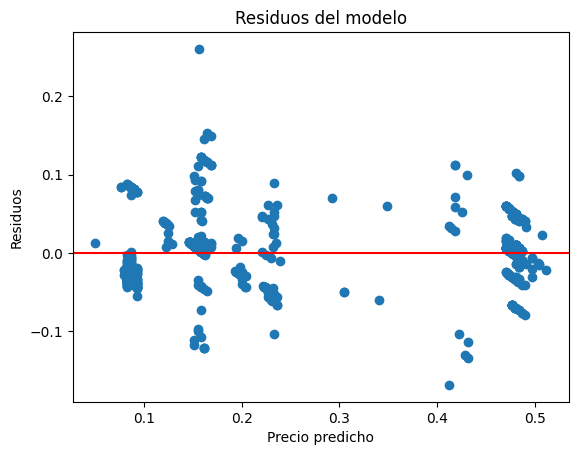

In [ ]:
residuos = y_test - y_pred_test

plt.scatter(y=residuos, x=y_pred_test)
plt.axhline(y=0.0, color='r', linestyle='-')
plt.ylabel('Residuos')
plt.xlabel('Precio predicho')
plt.title('Residuos del modelo')
plt.show()

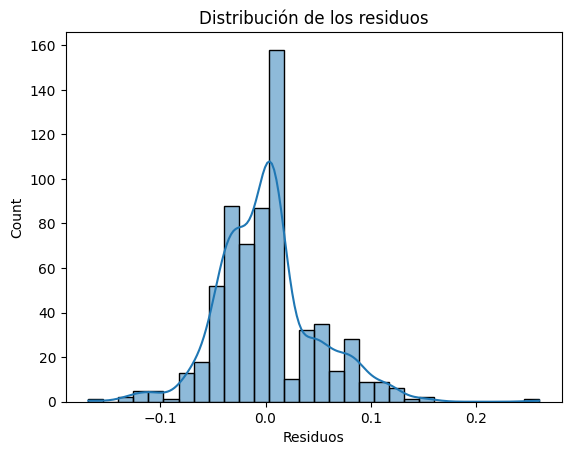

In [ ]:
sns.histplot(residuos, bins=30, kde=True)
plt.title('Distribución de los residuos')
plt.xlabel('Residuos')
plt.show()

In [ ]:
# Test de Shapiro-Wilk (normalidad de los residuos)
print(shapiro(residuos))

ShapiroResult(statistic=np.float64(0.954814061842204), pvalue=np.float64(3.319095977452406e-13))


In [ ]:
# Test de Durbin-Watson (independencia de los residuos)
print(durbin_watson(residuos))

2.0193417390745174


In [ ]:
# Test de Breusch-Pagan (homocedasticidad)
X_test_const = sm.add_constant(X_test.astype(float))
names = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
test_bp = smf.het_breuschpagan(residuos, X_test_const)
lzip(names, test_bp)

[('Lagrange multiplier statistic', np.float64(91.62918038554369)),
 ('p-value', np.float64(1.704254048863279e-11)),
 ('f-value', np.float64(5.755030081720363)),
 ('f p-value', np.float64(7.516302405519405e-13))]

###**Conclusiones sobre los supuestos analizados:**

En base a lo observado tanto a nivel gráfico como test estadísticos, se observa que:

1. Shapiro-Wilk, Normalidad: Shapiro p-valor = 3.319095977452406e-13, los residuos **NO** presentan una distribución normal.

2. Durbin-Watson, independencia de los residuos: el valor de 2.019 indica que existe una buena independencia entre los datos, este supuesto si se cumple, los residuos **Si son independientes entre sí**

3. Breusch-Pagan — homocedasticidad: p-value=1.70e-11, f p-value=7.52e-13. Con estos resultados se rechaza la hipótesis nula, por lo cual los datos **tienen heterocedasticidad**

Debido a los resultados obtenidos en el diagnóstico del modelo de regresión lineal, donde se evidenció la presencia de heterocedasticidad en los residuos, los p-valores reportados por statsmodels pierden precisión al no cumplirse el supuesto de varianza constante. Por esta razón se procederá a utilizar otro algotitmo, CatBoost, que no depende de estos supuestos y permite determinar las variables de mayor importancia predictora.

###**Modelo con CatBoost**

Como complemento a la regresión lineal, se entrenó un modelo CatBoost con el mismo objetivo (predecir el precio por kilogramo), pero usando las variables categóricas en su formato de texto original, sin necesidad de codificarlas a mano con dummies. La principal utilidad de este modelo es obtener el ranking de importancia de variables: qué tanto pesa cada factor a la hora de explicar el precio final de exportación.

Esto es de suma importancia ya que en base al resultado podría ser un punto estratégico de mejora del mercado de exportación.



In [ ]:
!pip install catboost --quiet

In [ ]:
# Para CatBoost se utilizan las variables categoricas en su formato de texto original
# (sin dummies, y sin agrupar los destinos en "Otros", ya que CatBoost las maneja de forma nativa)
df_cb = df[['precio_por_kg', 'Kgs. Netos', 'Estacion', 'País de Destino',
            'Via Transporte', 'Condición de Venta', 'ES CÓRDOBA?', 'ES CLÚSTER?']].copy()

categorical_cols = ['Estacion', 'País de Destino', 'Via Transporte', 'Condición de Venta', 'ES CÓRDOBA?', 'ES CLÚSTER?']

X_cb = df_cb.drop('precio_por_kg', axis=1)
y_cb = df_cb['precio_por_kg']

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X_cb, y_cb, test_size=0.25, random_state=42)

In [ ]:

model = CatBoostRegressor(random_seed=3, cat_features=categorical_cols, verbose=False)
model.fit(X_train_cb, y_train_cb)

CatBoostRegressor(cat_features=['Estacion', 'País de Destino', 'Via Transporte', 'Condición de Venta', 'ES CÓRDOBA?', 'ES CLÚSTER?'], loss_function='RMSE', random_seed=3, verbose=False)

In [ ]:
y_pred_train_cb = model.predict(X_train_cb)
y_pred_test_cb = model.predict(X_test_cb)

print('--- Metricas de Train (CatBoost) ---')
print('R2:', r2_score(y_train_cb, y_pred_train_cb))
print('RMSE:', np.sqrt(mean_squared_error(y_train_cb, y_pred_train_cb)))
print('MAE:', mean_absolute_error(y_train_cb, y_pred_train_cb))
print('MAPE:', mean_absolute_percentage_error(y_train_cb, y_pred_train_cb))

print()
print('--- Metricas de Test (CatBoost) ---')
print('R2:', r2_score(y_test_cb, y_pred_test_cb))
print('RMSE:', np.sqrt(mean_squared_error(y_test_cb, y_pred_test_cb)))
print('MAE:', mean_absolute_error(y_test_cb, y_pred_test_cb))
print('MAPE:', mean_absolute_percentage_error(y_test_cb, y_pred_test_cb))

--- Metricas de Train (CatBoost) ---
R2: 0.9763712657556666
RMSE: 0.025938107325586202
MAE: 0.01728519523677815
MAPE: 0.10513072618348664

--- Metricas de Test (CatBoost) ---
R2: 0.9673197205267857
RMSE: 0.03061205132976493
MAE: 0.01986733472555242
MAPE: 0.10927369412651562


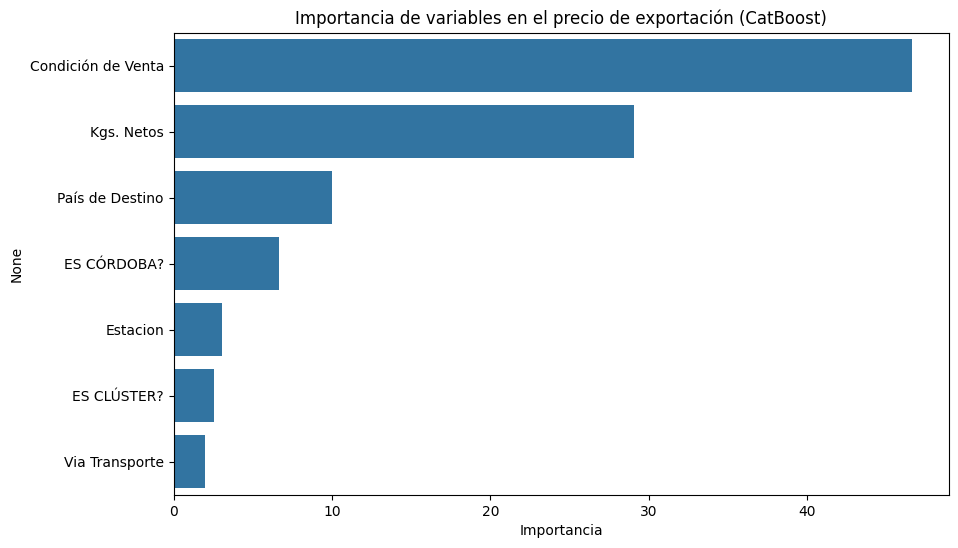

In [ ]:
# Importancia de cada variable en el modelo
feature_importance = model.get_feature_importance()
feature_names = X_cb.columns

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance, y=feature_names, order=feature_names[np.argsort(-feature_importance)])
plt.title('Importancia de variables en el precio de exportación (CatBoost)')
plt.xlabel('Importancia')
plt.show()

###**Conclusiones de este modelo:**

El modelo de CatBoost alcanzó un valor de  R² de 0.976 tanto en el dataset Train como Test, indicando que, además de ser un modelo que explica el 97% de la variabilidad de los datos, además no presenta un sobreajuste de los datos (overfiting).

Por otra parte se observó un valor mucho más bajo en los errores RMSE MAE y MAPE. En este punto es de especial interés el error MAPE, ya que anteriormente era de 24% mientras que con este modelo es de 10,9%, es decir que los datos predichos solo se desvían casi un 11% del valor real, mejorando mucho la capacidad de predicción del modelo.

Resumen de los valores obtenidos del modelo:

| Métrica | Train | Test |
|---------|------:|-----:|
| R²      | 0.976 | 0.967 |
| RMSE    | 0.026 | 0.031 |
| MAE     | 0.017 | 0.020 |
| MAPE    | 10.5% | 10.9% |




--------------------------------------------------------------------------------
#**Conlcusiones generales de los 3 modelos de Regresión Lineal Múltiple**
--------------------------------------------------------------------------------

| Métrica | Lineal (Test) | CatBoost (Test) |
|---------|---------------:|-----------------:|
| R²      | 0.9238 | 0.9673 |
| RMSE    | 0.0468 | 0.0306 |
| MAE     | 0.0338 | 0.0199 |
| MAPE    | 24.36% | 10.93% |

El mejor desempeño del modelo de CatBoost se debe a que existen relaciones no lineales e interacciones entre las variables utilizadas para predecir el precio por kg de alfalfa. Estas relaciones no lineales no pudieron ser captadas por los modelos OLS pero si pudieron ser captadas por CatBost.

Por otro lado, en base a los resultados del modelo, las variables que más condicionan el precio de kg, y por lo tanto **deberían ser foco de análisis para mejorar la posición competitiva del mercado exportador argentino** son:

* *Condición de Venta (Incoterms):* se posiciona como la variable más relevante en ambos enfoques, lo que indica que los términos de negociación comercial pactados en cada operación tienen un impacto directo y sustancial sobre el precio obtenido. Esto sugiere una oportunidad concreta para que las exportadoras evalúen bajo qué condiciones están vendiendo mayoritariamente y si existe margen para renegociar términos más favorables.

* *Kgs. Netos (volumen exportado):* su fuerte peso no lineal en CatBoost indica que sería valioso estudiar cómo varía el precio según distintos rangos de volumen, para identificar una eventual escala óptima de operación y orientar decisiones sobre consolidación de envíos o negociación por volumen.

* *País de Destino:* su relevancia en ambos modelos confirma que el precio varía sistemáticamente según el mercado de destino, reforzando la importancia de identificar aquellos destinos donde Argentina podría reposicionar su oferta o mejorar condiciones comerciales, en línea con las oportunidades detectadas en el análisis del mercado mundial.
Origen geográfico de la operación

* *ES_CORDOBA:* su efecto positivo y significativo sugiere que el origen de la operación también influye en el precio obtenido, lo cual amerita investigar si se debe a mejor infraestructura logística, calidad diferencial del producto o mayor poder de negociación, para eventualmente replicar esas condiciones en otras provincias exportadoras.




-------------------------------------
###En síntesis, el análisis combinado de ambos modelos no solo permite identificar qué variables importan, sino que evidencia que sus efectos son más complejos de lo que una regresión lineal simple puede reflejar. Esto sugiere que las estrategias comerciales de las exportadoras argentinas deberían considerar combinaciones específicas de condición de venta, volumen y destino, en lugar de asumir que cada factor actúa de forma aislada y proporcional sobre el precio final.
-------------------------------------
